# Life Expectancy Clustering Using WHO Data -  Project

## Objective

This project aims to cluster countries with similar life expectancy patterns using unsupervised machine learning techniques. By leveraging WHO health, economic, demographic, and social indicators, the analysis uncovers hidden global health patterns, compares developed and developing nations, and identifies key factors influencing life expectancy. The insights generated can support data-driven public health planning and policy decisions.

## Dataset Description 
| **Feature Name**                | **Description**                                                    |
| ------------------------------- | ------------------------------------------------------------------ |
| Country                         | Name of the country                                                |
| Year                            | Year of data collection                                            |
| Status                          | Development status of the country (Developed / Developing)         |
| Life expectancy                 | Average life expectancy at birth (years)                           |
| Adult Mortality                 | Probability of dying between ages 15 and 60 per 1,000 population   |
| Infant deaths                   | Number of infant deaths per 1,000 population                       |
| Alcohol                         | Average alcohol consumption per capita (liters)                    |
| Percentage expenditure          | Health expenditure as a percentage of GDP                          |
| Hepatitis B                     | Immunization coverage for Hepatitis B (%)                          |
| Measles                         | Number of reported measles cases                                   |
| BMI                             | Average Body Mass Index of the population                          |
| Under-five deaths               | Number of deaths of children under five per 1,000 population       |
| Polio                           | Polio immunization coverage (%)                                    |
| Total expenditure               | Government health expenditure as a percentage of total expenditure |
| Diphtheria                      | DPT immunization coverage (%)                                      |
| HIV/AIDS                        | Deaths per 1,000 live births due to HIV/AIDS                       |
| GDP                             | Gross Domestic Product per capita                                  |
| Population                      | Total population of the country                                    |
| Thinness 1–19 years             | Prevalence of thinness among children and adolescents (%)          |
| Thinness 5–9 years              | Prevalence of thinness among children aged 5–9 (%)                 |
| Income composition of resources | Human Development Index (HDI) income component                     |
| Schooling                       | Average number of years of schooling                               |


In [1]:
# Importing packages
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore') 
import math

In [2]:
data = pd.read_csv(r'D:\ds ai ml\DS@AI\00-portfolio-projects\clustering\Life Expectancy Data_WHO.csv')
data.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [4]:
data.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [5]:
data.shape

(2938, 22)

## Data Cleaning

In [6]:
# column name formatting
data.columns =( data.columns.str.strip()
               .str.lower()
               .str.replace(' ','_')
)

In [7]:
data.columns

Index(['country', 'year', 'status', 'life_expectancy', 'adult_mortality',
       'infant_deaths', 'alcohol', 'percentage_expenditure', 'hepatitis_b',
       'measles', 'bmi', 'under-five_deaths', 'polio', 'total_expenditure',
       'diphtheria', 'hiv/aids', 'gdp', 'population', 'thinness__1-19_years',
       'thinness_5-9_years', 'income_composition_of_resources', 'schooling'],
      dtype='object')

In [8]:
# checking presence any negative values
cols_to_check = data.select_dtypes(exclude = 'object').columns

for col in cols_to_check:
    print(col, (data[col] < 0).sum())

year 0
life_expectancy 0
adult_mortality 0
infant_deaths 0
alcohol 0
percentage_expenditure 0
hepatitis_b 0
measles 0
bmi 0
under-five_deaths 0
polio 0
total_expenditure 0
diphtheria 0
hiv/aids 0
gdp 0
population 0
thinness__1-19_years 0
thinness_5-9_years 0
income_composition_of_resources 0
schooling 0


In [9]:
data[['year']].value_counts()

year
2013    193
2000    183
2001    183
2002    183
2003    183
2004    183
2005    183
2006    183
2007    183
2008    183
2009    183
2010    183
2011    183
2012    183
2014    183
2015    183
Name: count, dtype: int64

#### Data cleaning Summary
Corrected inconsistent spacing in column names and verified the dataset for the presence of negative values.

## Exploratory Data Analysis (EDA)¶

In [10]:
data.describe()

,year,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under-five_deaths,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness__1-19_years,thinness_5-9_years,income_composition_of_resources,schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


#### Observation
- Dataset covers the period 2000–2015

- Life expectancy averages around 69 years, with wide variation across countries

- Adult mortality, infant deaths, under-five deaths and HIV/AIDS show high dispersion, indicating global health inequality

- GDP and population are highly skewed, reflecting large economic differences between countries

- Immunization coverage (Hepatitis B, Polio, Diphtheria) is generally high but uneven across regions

- Several variables contain missing values

- Features vary significantly in scale and distribution, requiring normalization and preprocessing before clustering

In [11]:
def hist_plot(df, cols=None, n_cols=3):
   
    # Select numeric columns if cols not provided
    if cols is None:
        cols = df.select_dtypes(include=np.number).columns
    
    if len(cols) == 0:
        print("No numeric columns to plot.")
        return

    n_plots = len(cols)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        sns.histplot(
            data=df,
            x=col,
            kde=True,
            ax=axes[i]
        )
        axes[i].set_title(f'Distribution of {col}', fontsize=14)
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel('Count', fontsize=12)

    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


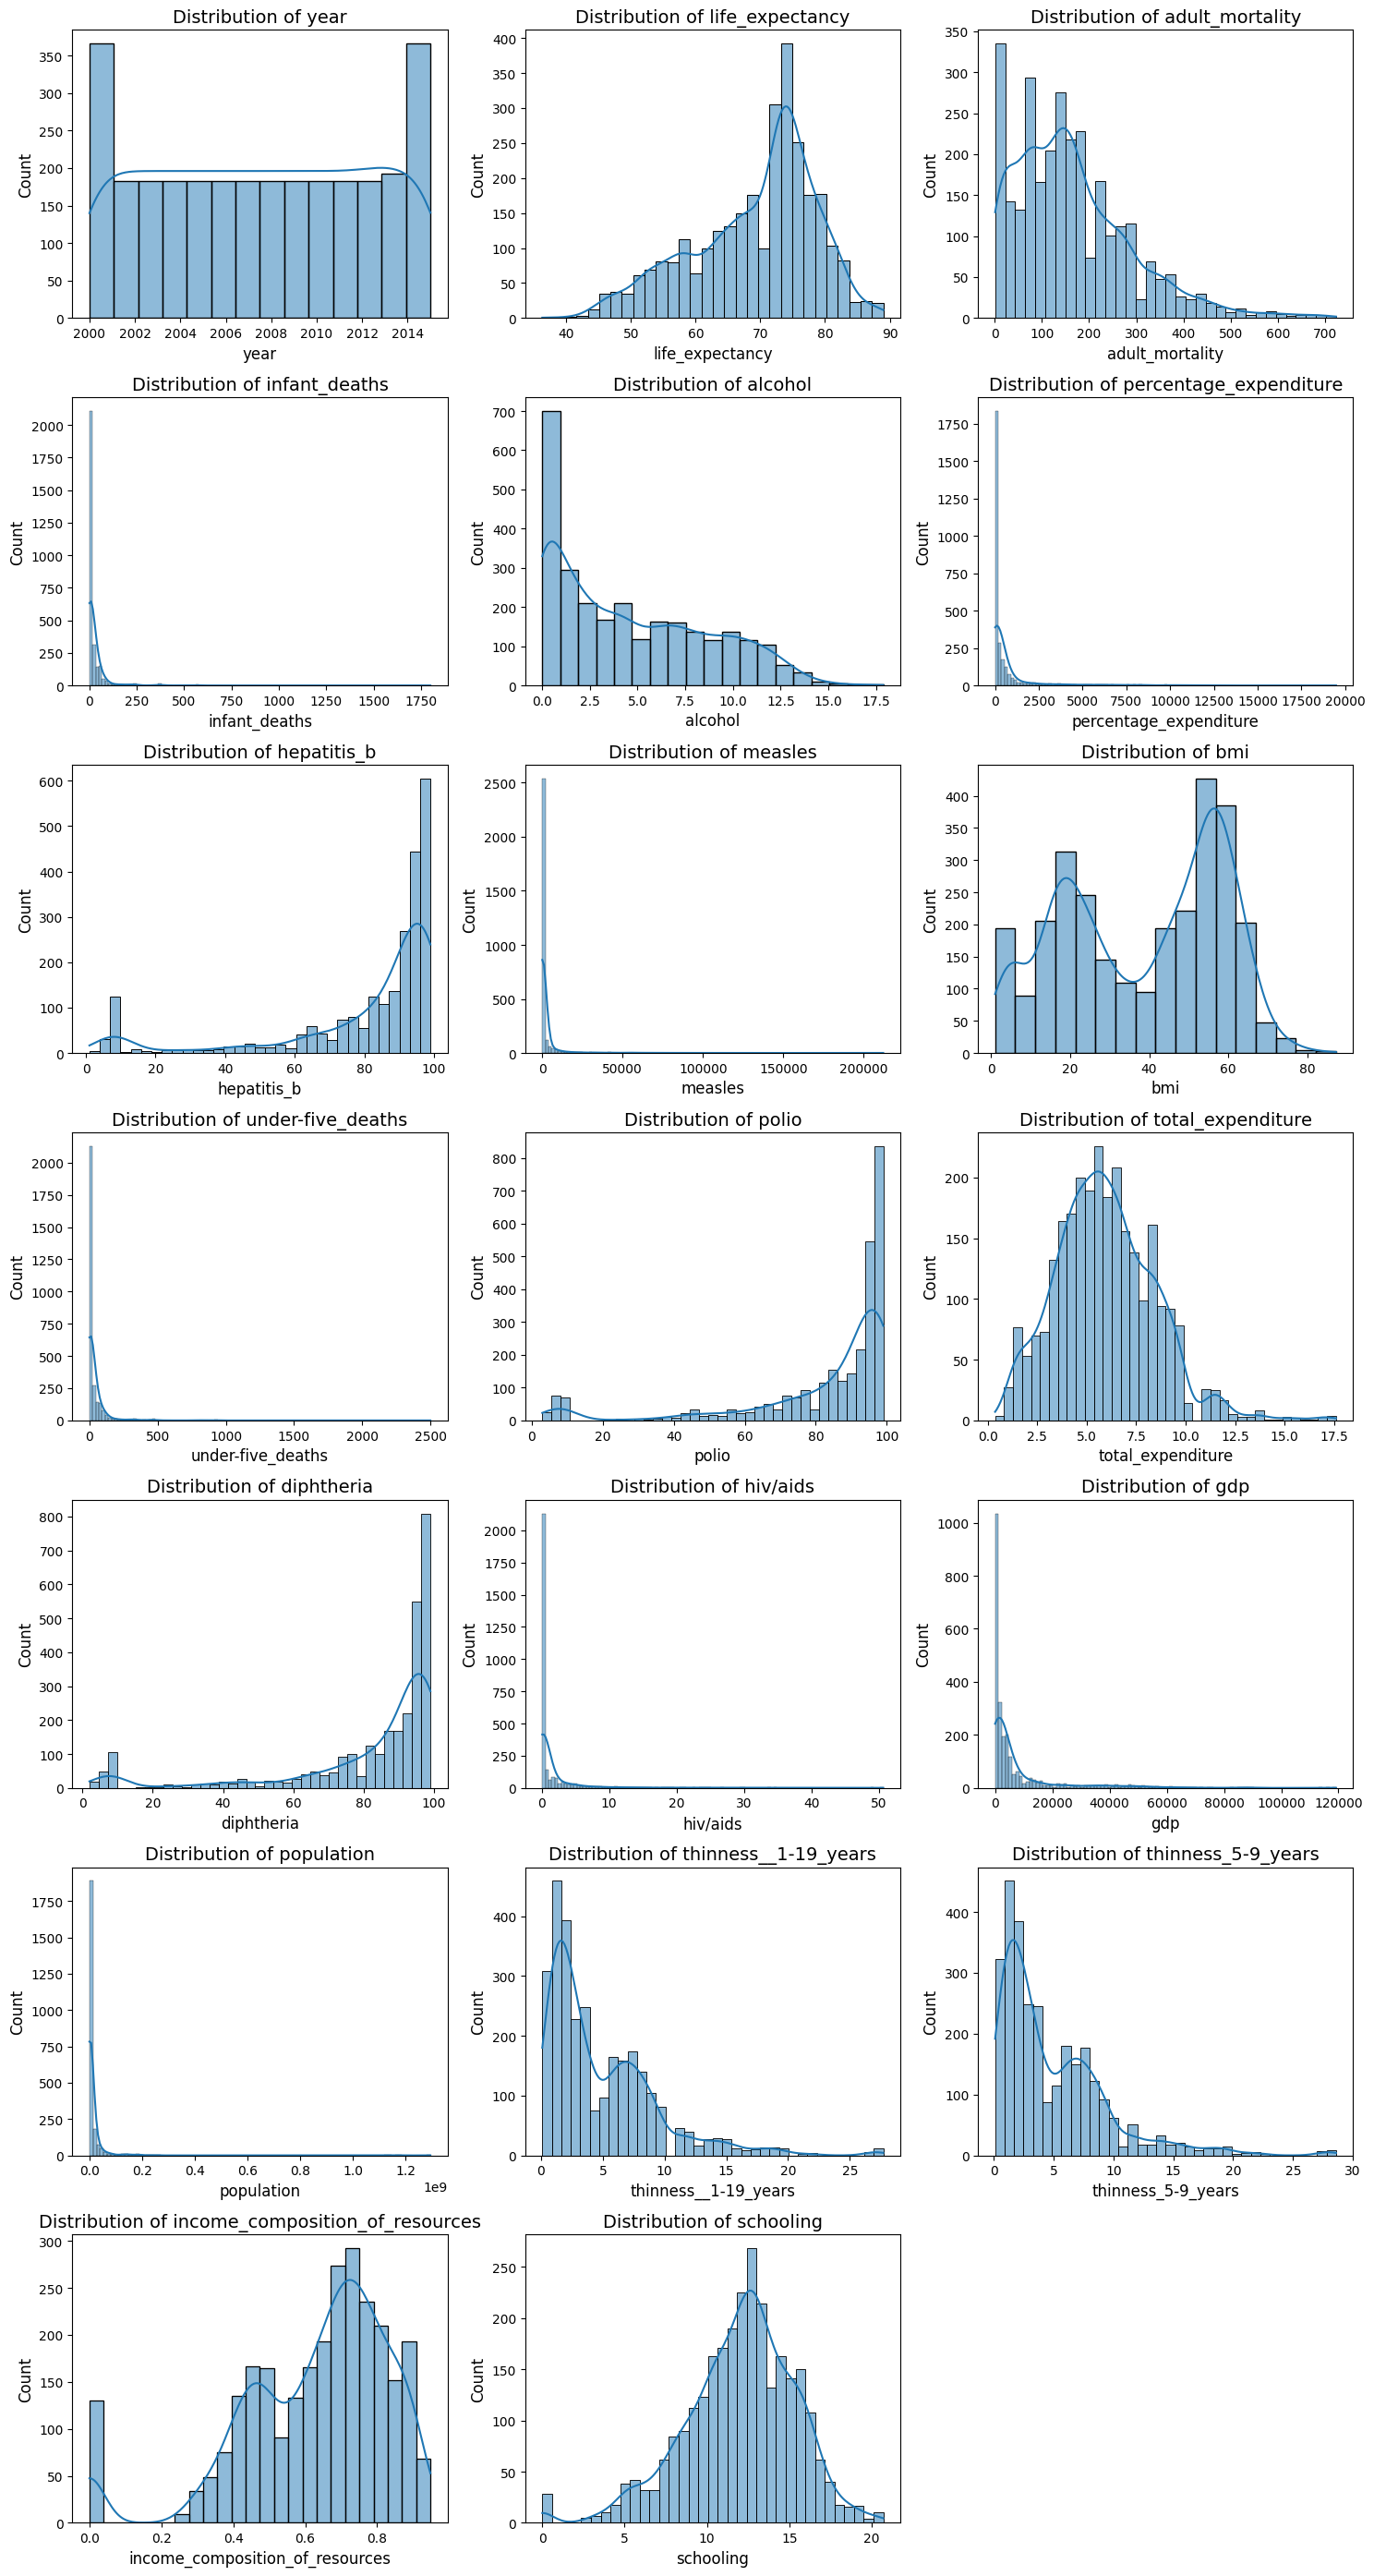

In [12]:
hist_plot(data)

In [13]:
def cat_plot(df, cols=None, n_cols = 3):
    # If no columns are provided, select all non-numeric columns
    if cols is None:
        cols = df.select_dtypes(exclude=np.number).columns
        
    if len(cols) == 0:
        print("No categorical columns to plot.")
        return 

    
    n_plots = len(cols)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10*n_cols, 6*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]

        sns.countplot(
            x=col,
            data=df,
            palette='viridis',
            ax=ax
        )

        ax.set_title(f'Count of {col}', fontsize=18)

        # Rotate x-axis labels
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14)

        # Add count labels
        for container in ax.containers:
            ax.bar_label(container, padding=3, fontsize=10)

    # Remove unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


In [14]:
data.describe(include= 'O')

,country,status
count,2938,2938
unique,193,2
top,Afghanistan,Developing
freq,16,2426


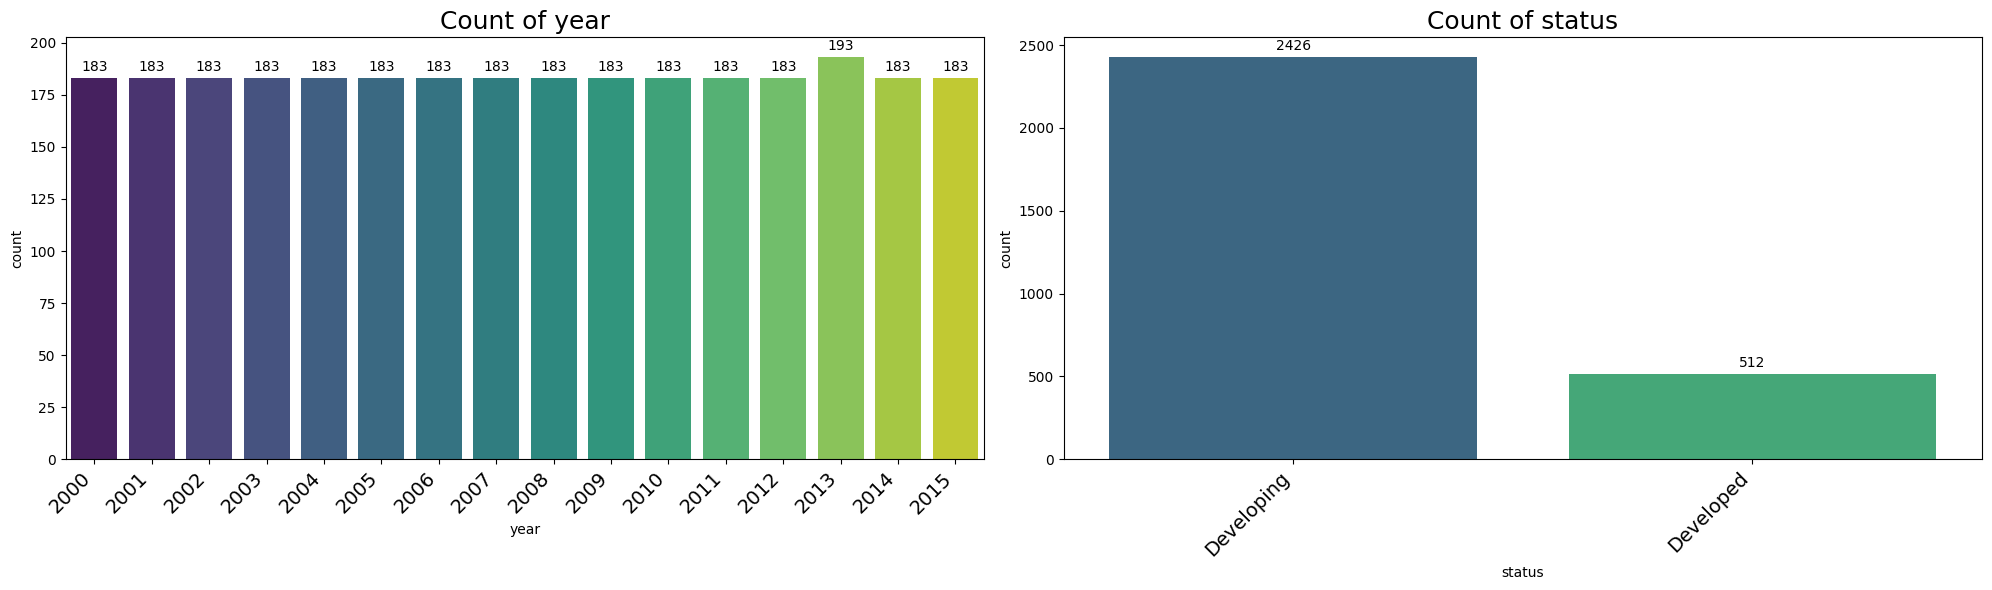

In [15]:
cat_plot(data,cols =['year','status'])

- Developing countries dominate the dataset, with 2,426 records, compared to developed countries.

- The dataset shows a balanced representation across all years.

### Outlier Analysis

In [16]:
def box_plot(df, cols=None, n_cols=4, color='skyblue'):
        
    # Select numeric columns if cols not provided
    if cols is None:
        cols = df.select_dtypes(include=np.number).columns
    
    if len(cols) == 0:
        print("No numeric columns to plot.")
        return
    
    n_plots = len(cols)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        sns.boxplot(
            y=df[col],
            ax=ax,
            color=color
        )
        ax.set_title(f'Boxplot of {col}', fontsize=14)
        ax.set_ylabel(col, fontsize=12)

    # Remove empty axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


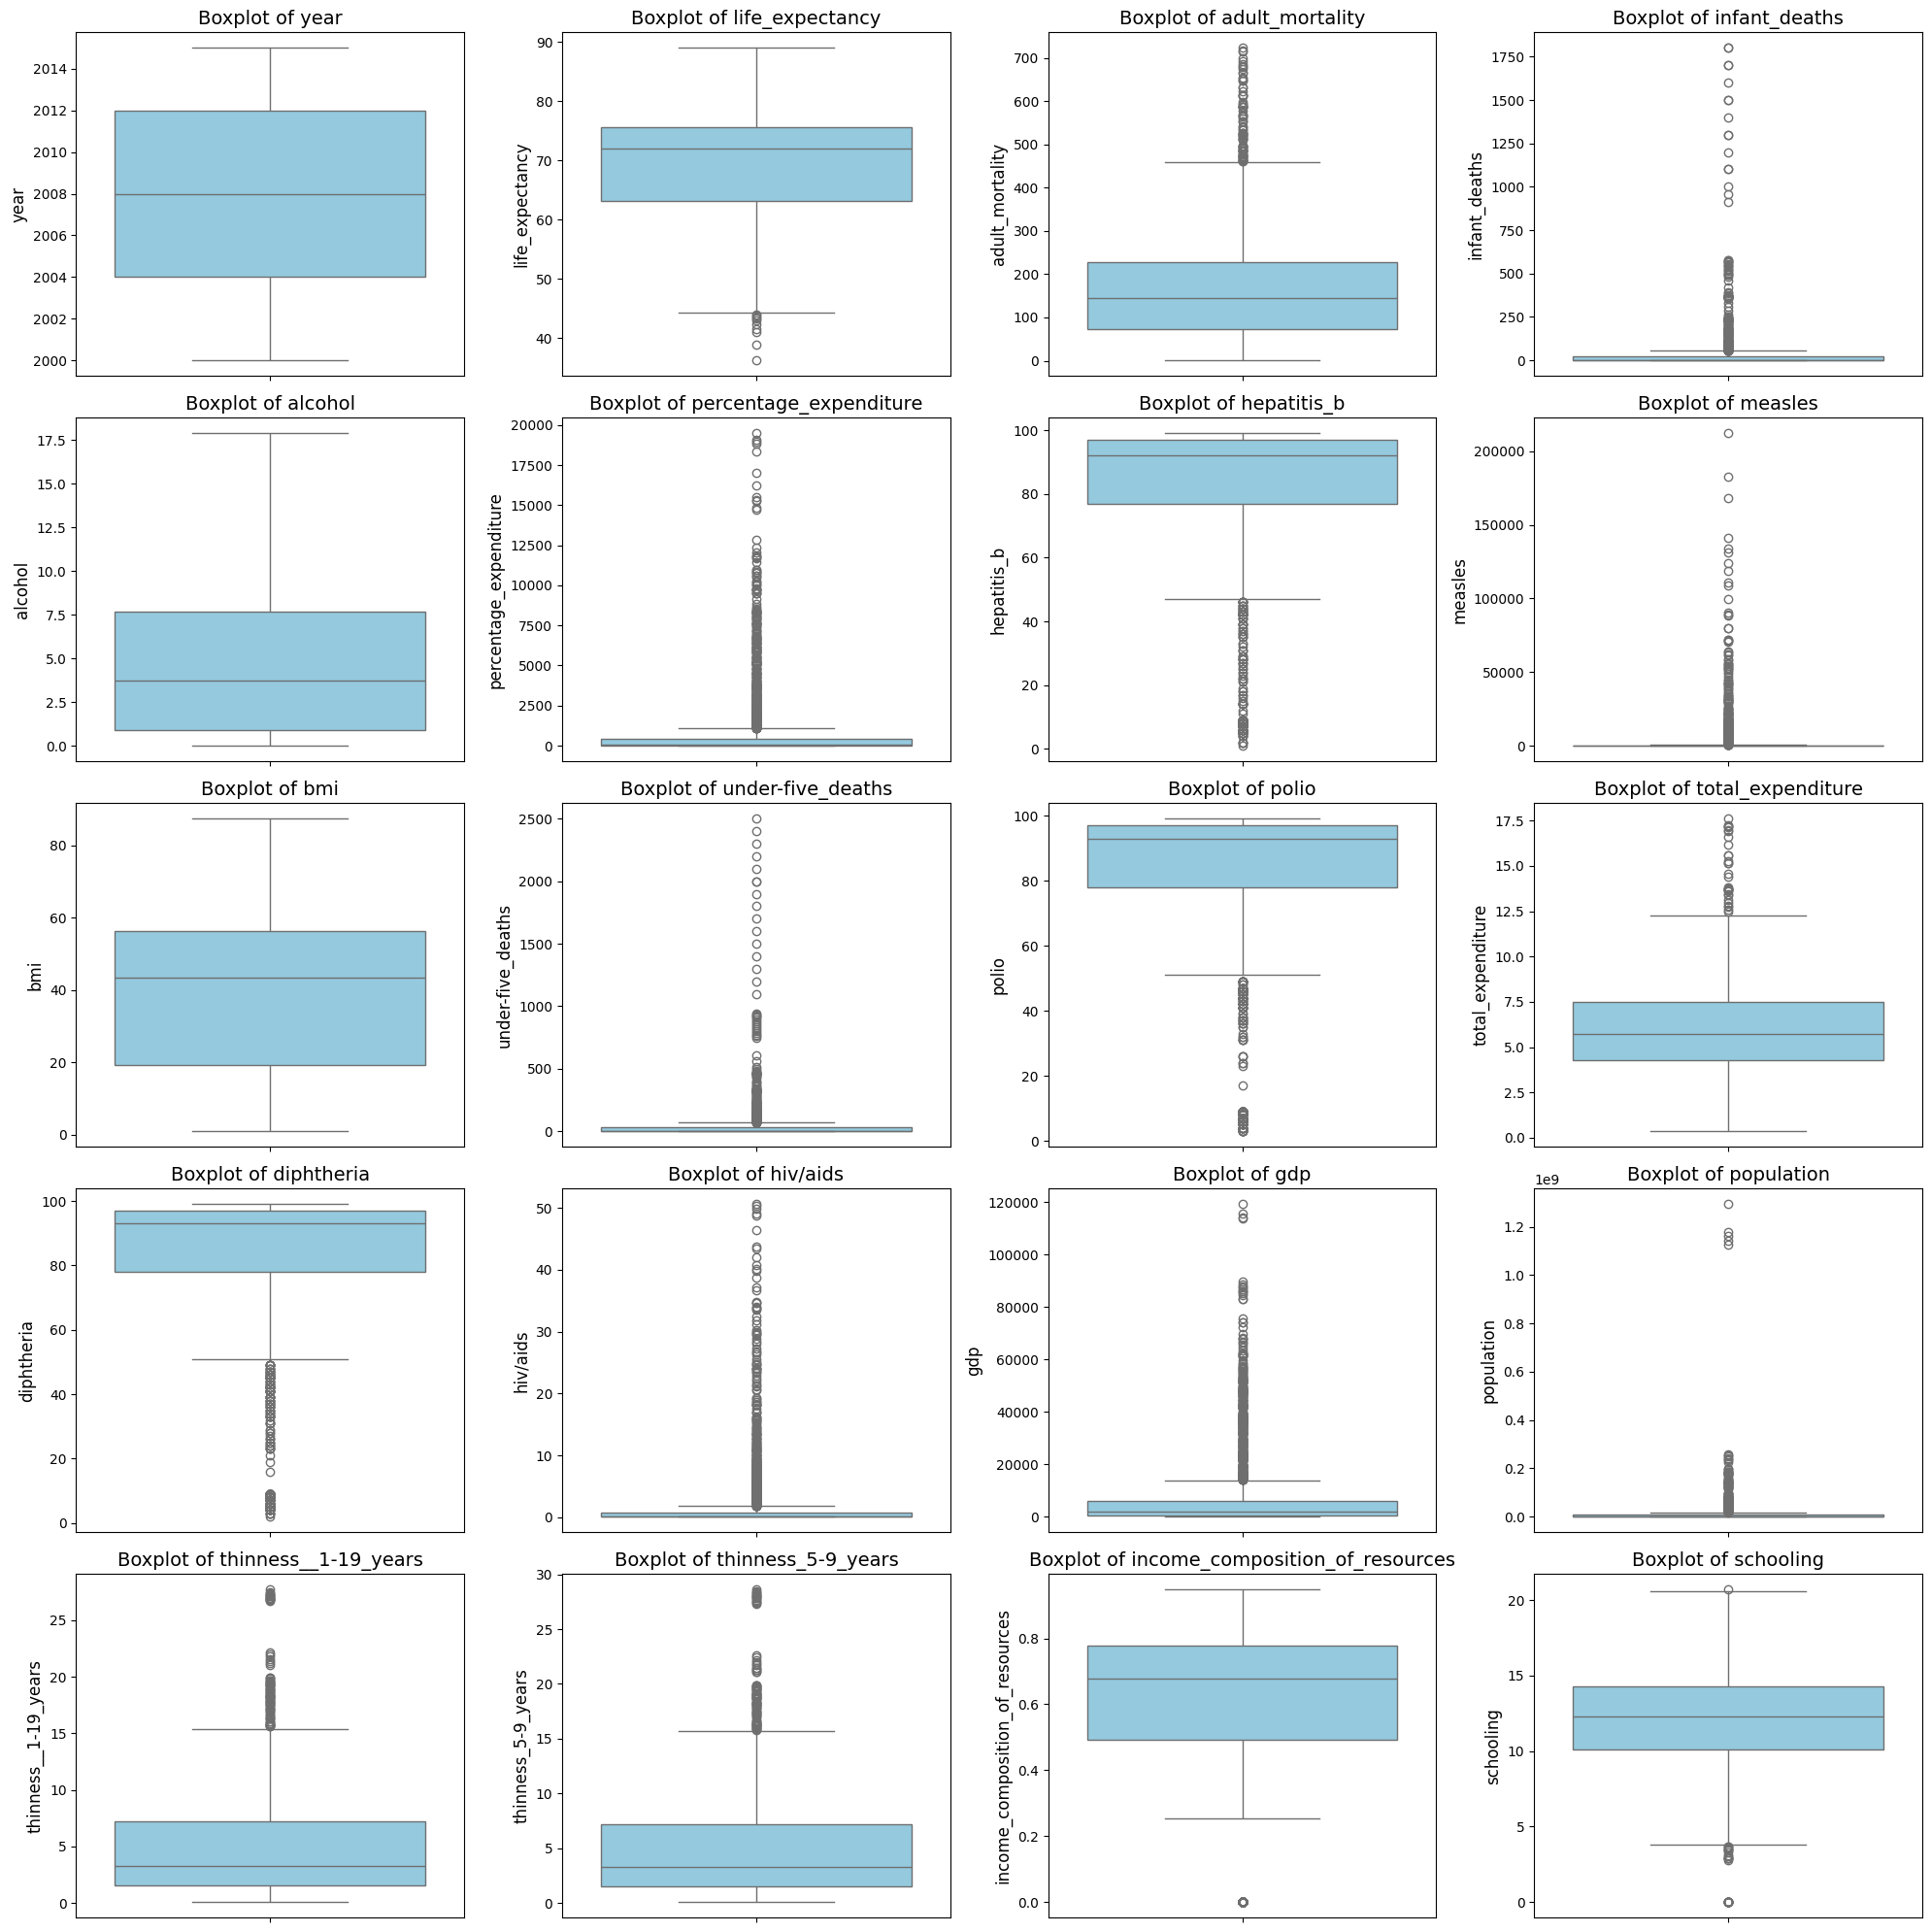

In [17]:
box_plot(data)

In [18]:
data.shape

(2938, 22)

In [19]:
#Treating Outliers
cols = data.select_dtypes(include = np.number).columns
for name in cols:
    Q1 = data[name].quantile(0.25)
    Q3 = data[name].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    data[name] = data[name].clip(lower, upper)


In [20]:
data.shape

(2938, 22)

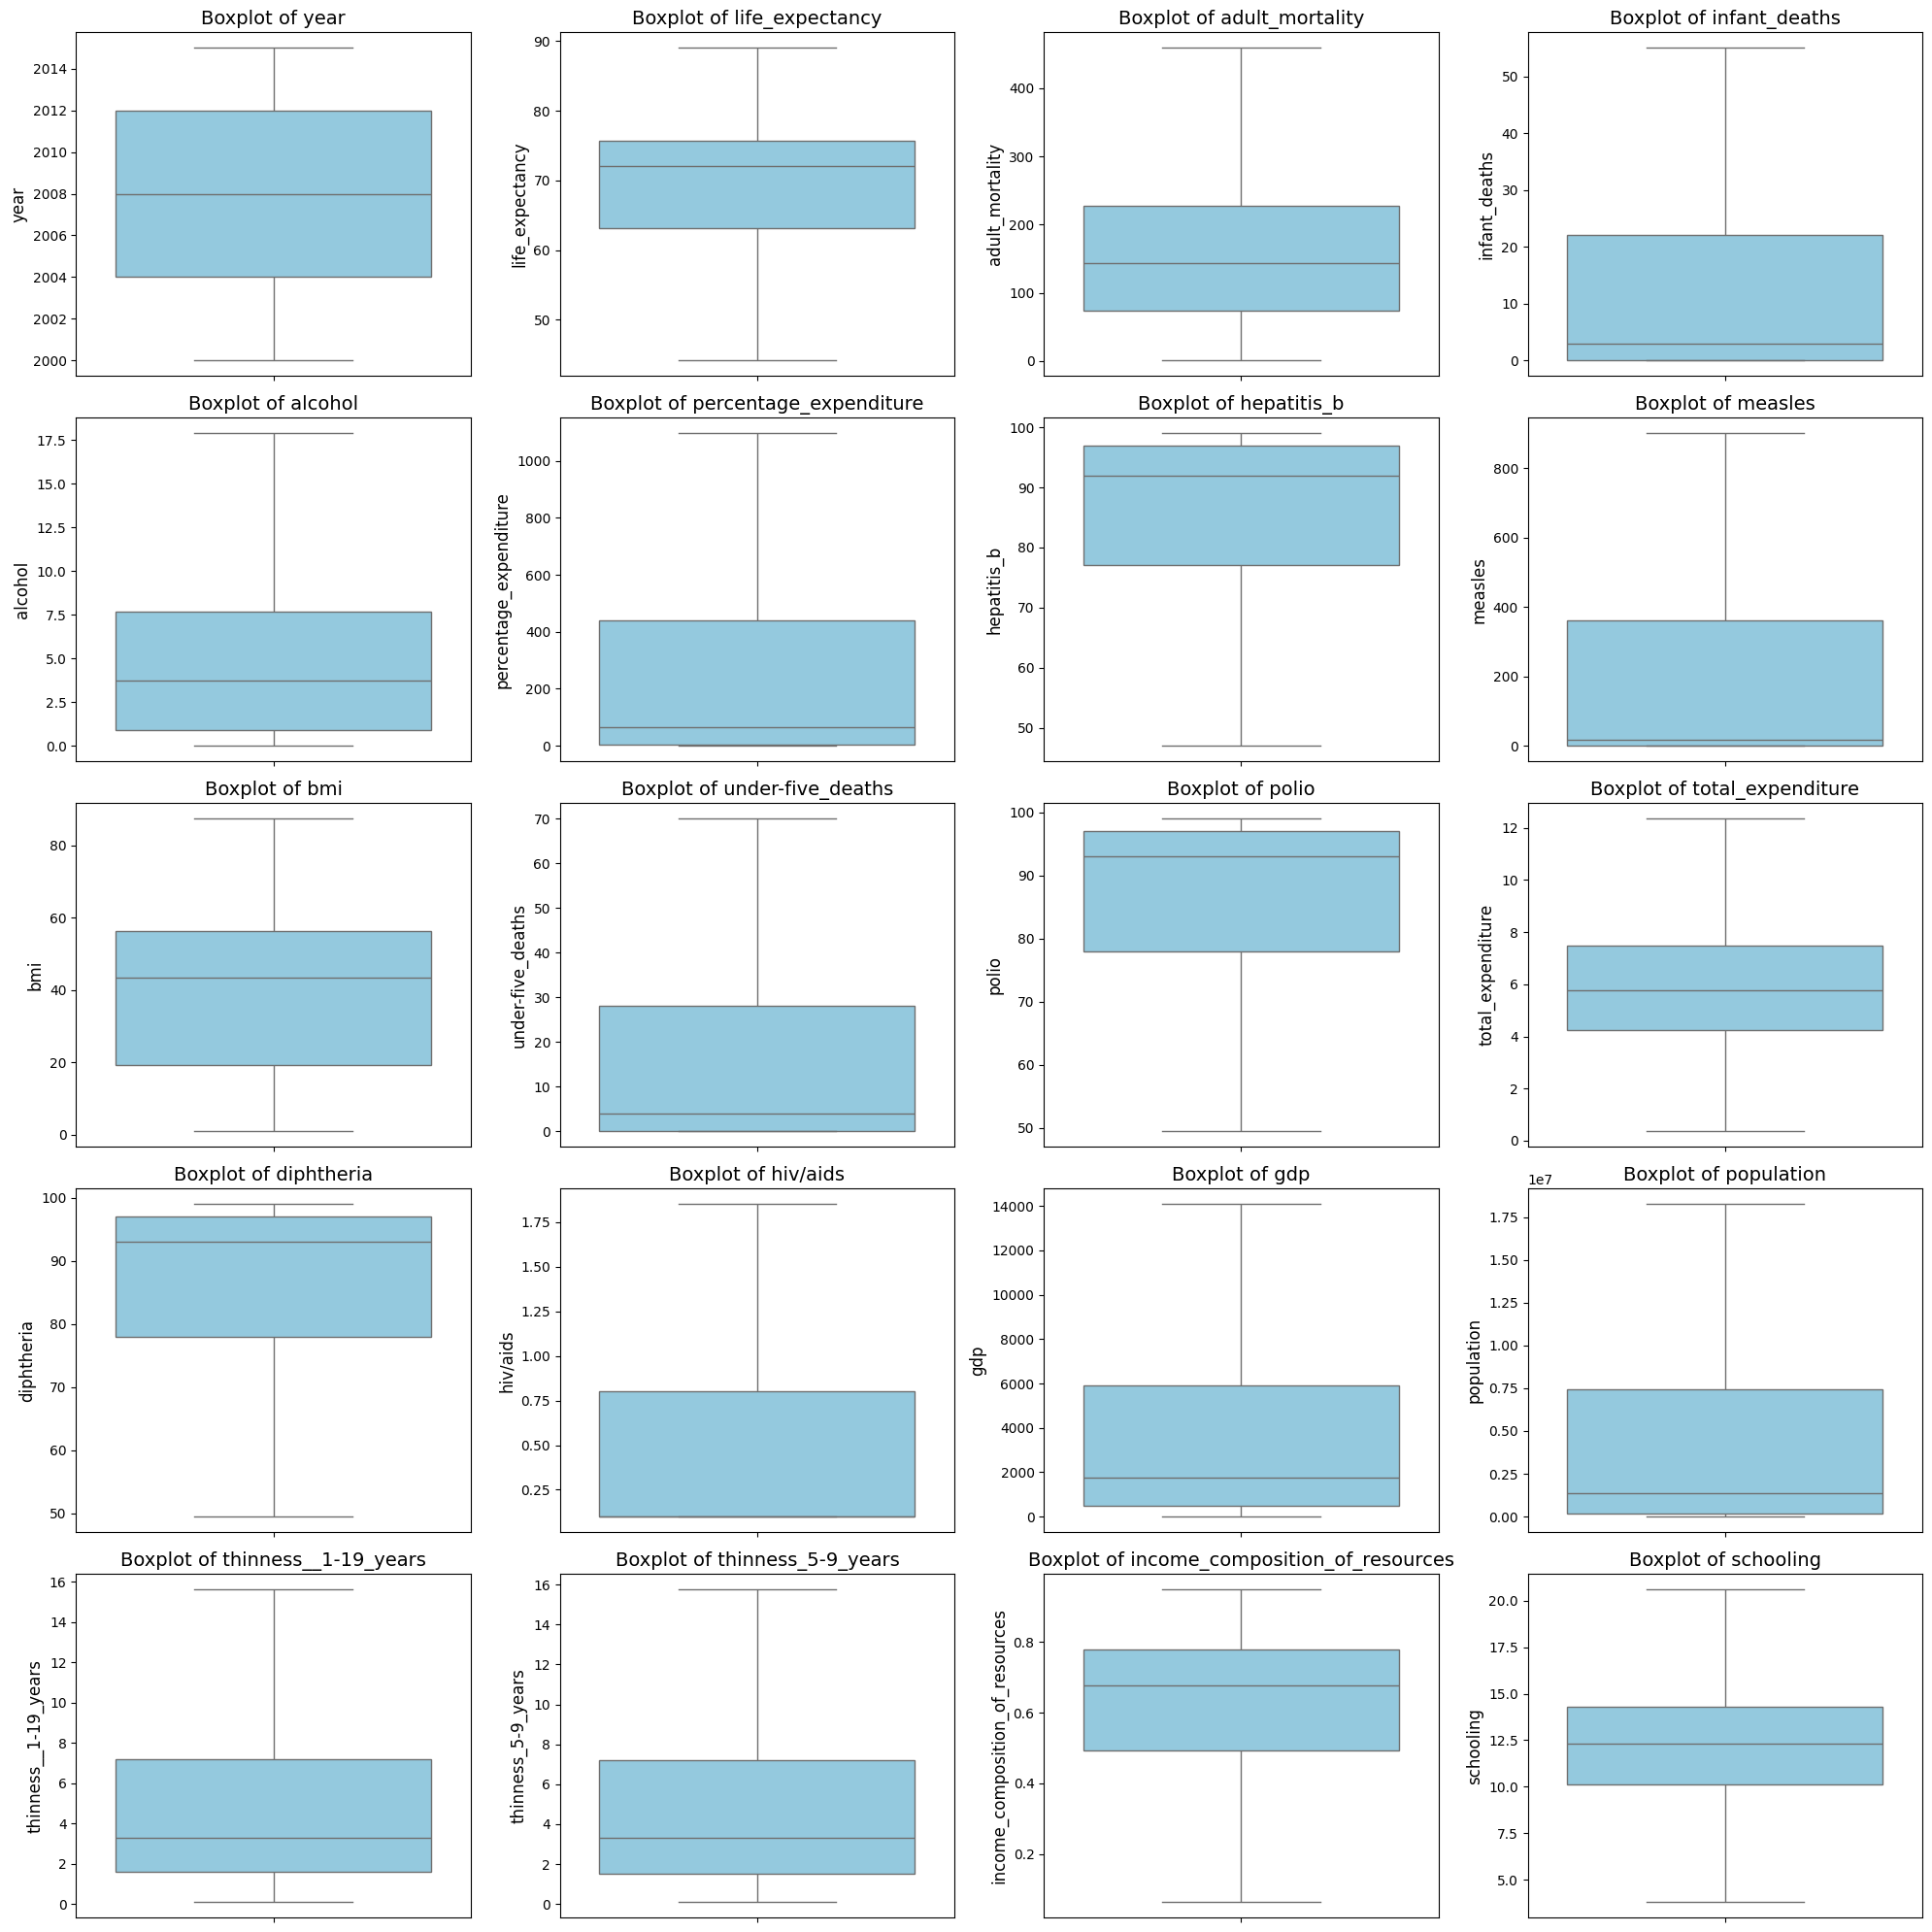

In [21]:
box_plot(data)

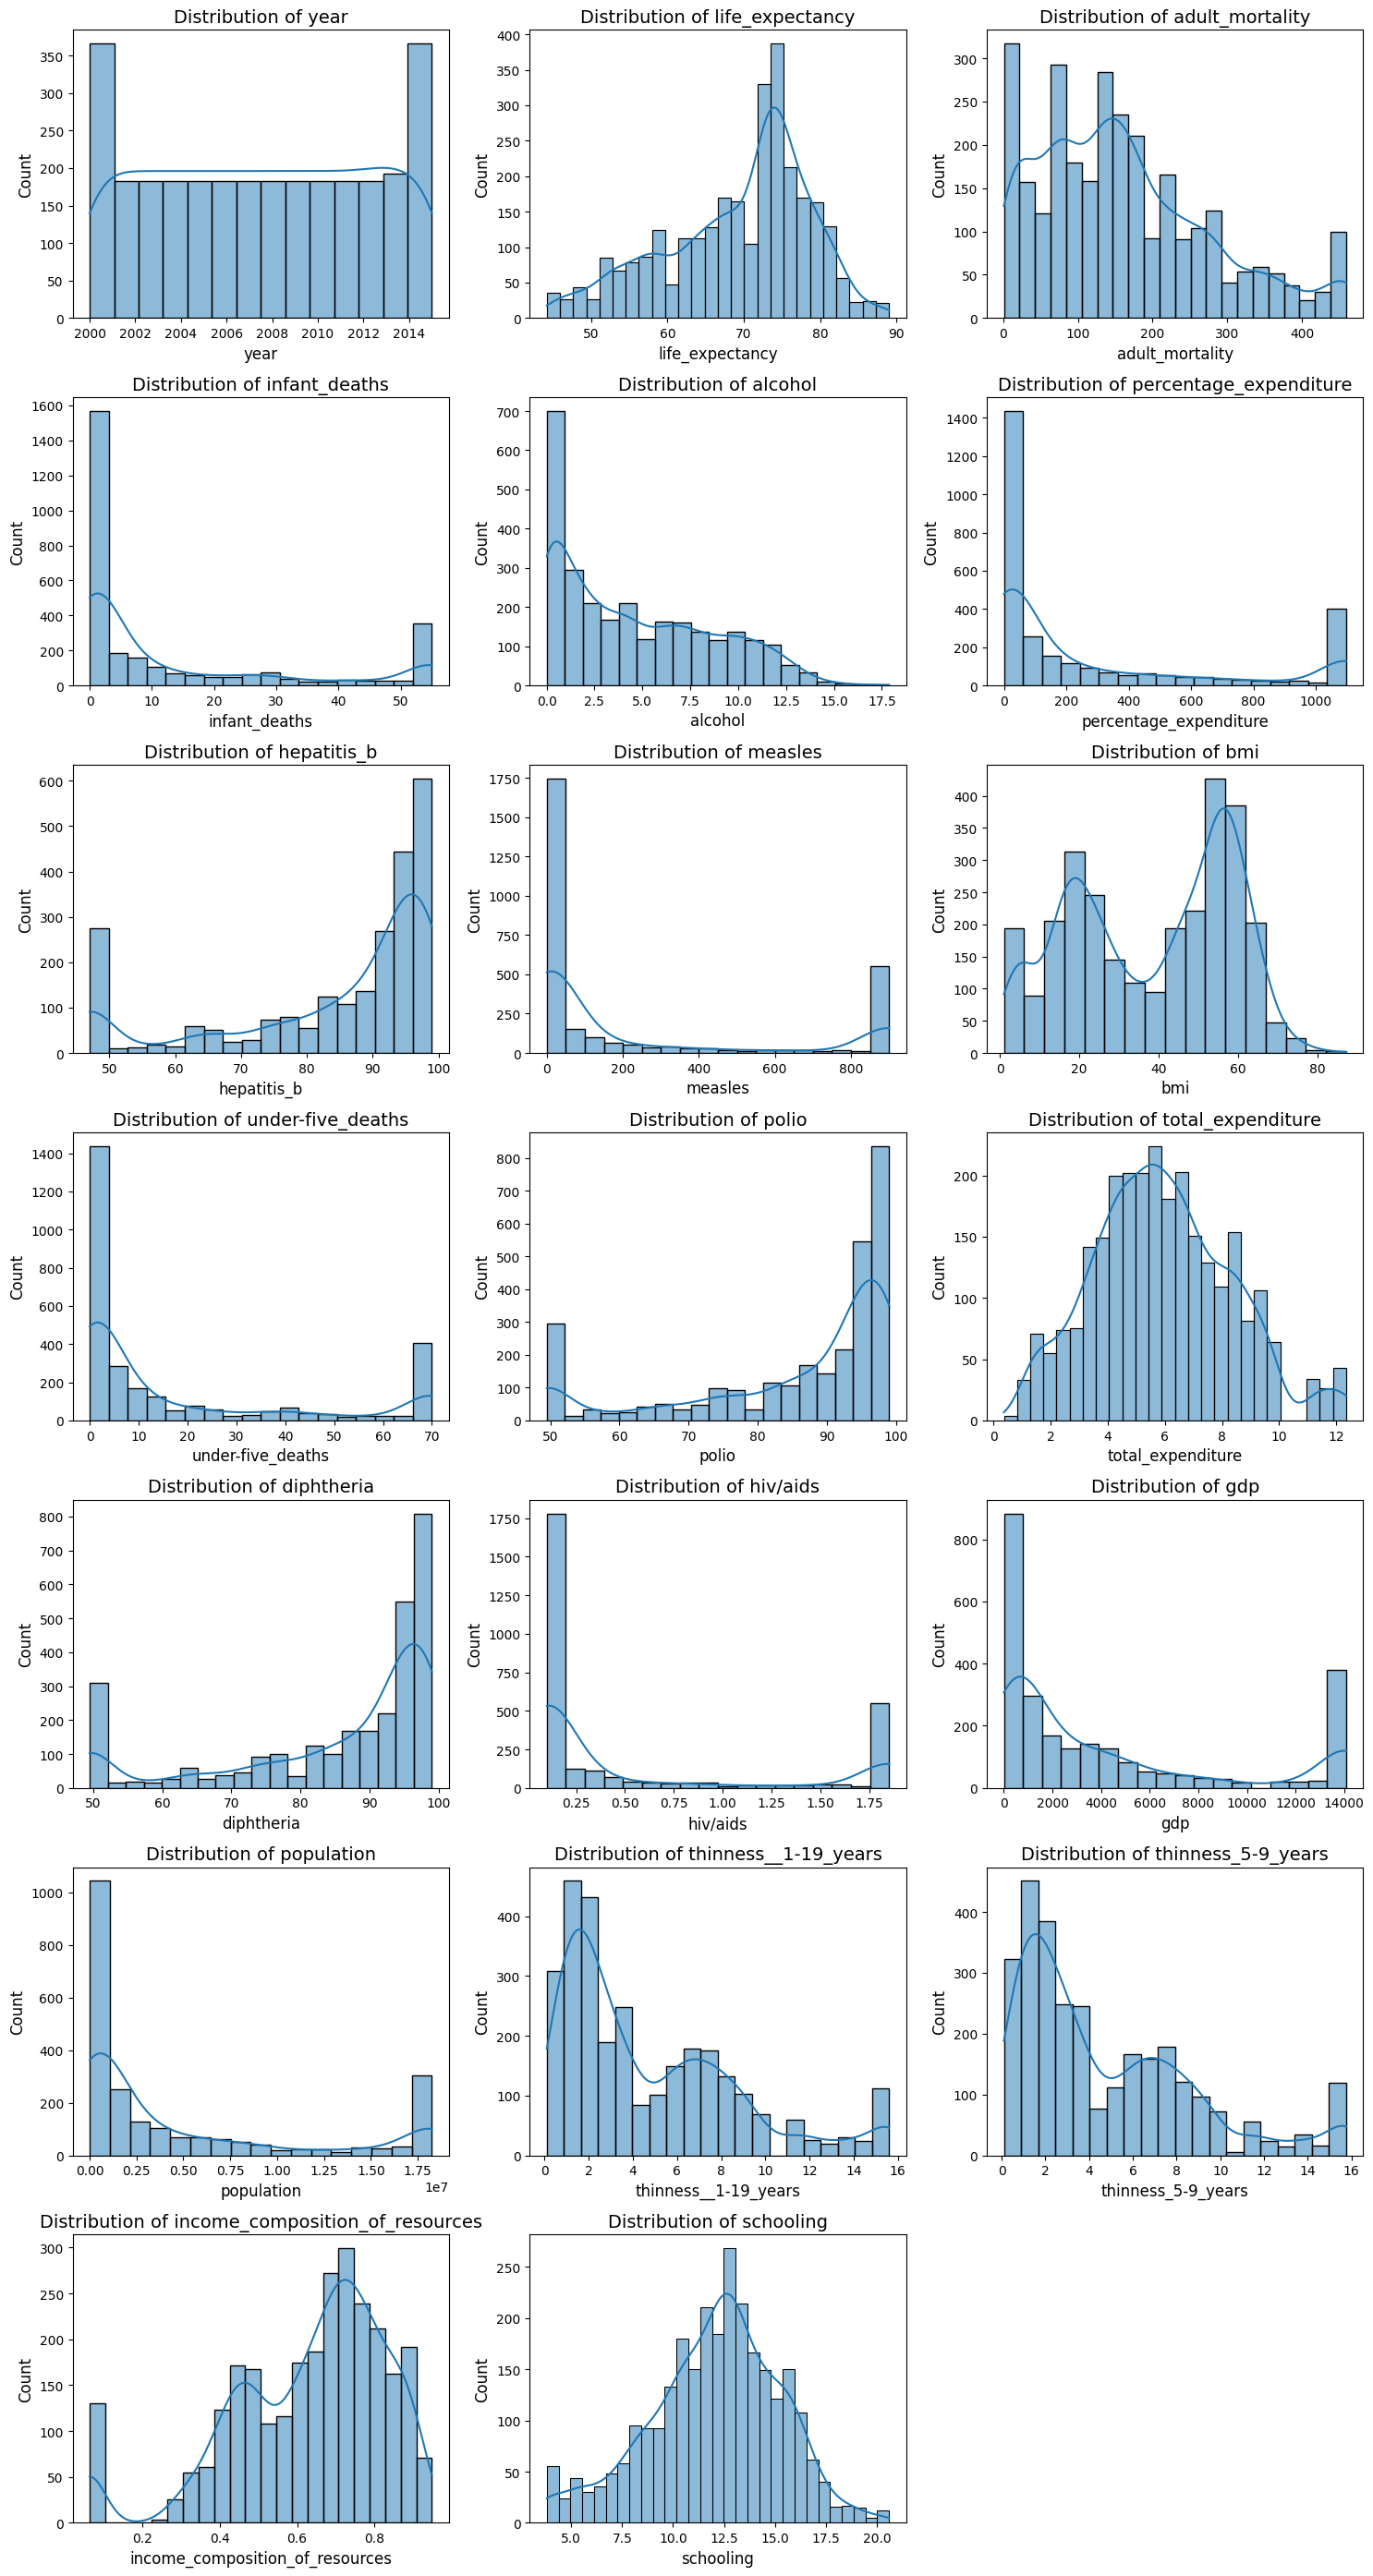

In [22]:
hist_plot(data)

#### Distribution of Data Observation
Most features remain skewed even after outlier treatment, suggesting asymmetry in the data distributions.

## Missing value analysis

In [23]:
data.isna().sum()

country                              0
year                                 0
status                               0
life_expectancy                     10
adult_mortality                     10
infant_deaths                        0
alcohol                            194
percentage_expenditure               0
hepatitis_b                        553
measles                              0
bmi                                 34
under-five_deaths                    0
polio                               19
total_expenditure                  226
diphtheria                          19
hiv/aids                             0
gdp                                448
population                         652
thinness__1-19_years                34
thinness_5-9_years                  34
income_composition_of_resources    167
schooling                          163
dtype: int64

In [24]:
data.duplicated().sum()

np.int64(0)

In [25]:
# Data Imputation
col = data.columns
for col_name in col:
    if data[col_name].dtypes=='object':
        data[col_name] = data[col_name].fillna(data[col_name].mode()[0])   
                                                                          
    else:        
        data[col_name] = data[col_name].fillna(data[col_name].median())

In [26]:
data.isna().sum()

country                            0
year                               0
status                             0
life_expectancy                    0
adult_mortality                    0
infant_deaths                      0
alcohol                            0
percentage_expenditure             0
hepatitis_b                        0
measles                            0
bmi                                0
under-five_deaths                  0
polio                              0
total_expenditure                  0
diphtheria                         0
hiv/aids                           0
gdp                                0
population                         0
thinness__1-19_years               0
thinness_5-9_years                 0
income_composition_of_resources    0
schooling                          0
dtype: int64

### Observation
Due to skewed distributions, missing values were imputed using the median.

# Encoding

In [27]:
data_k = data.copy() # Data for Kmeans
data_hr = data.copy() # Data for Hierarchical clustering

In [28]:
# We will drop the 'country' feature because it is unique for each country and would not add value to clustering.
df = data.copy()

In [29]:
df= df.drop('country', axis = 1)

In [30]:
from sklearn.preprocessing import OrdinalEncoder
# Define the order of values
Oe = OrdinalEncoder(categories=[["Developing","Developed"]])

df["status"]=Oe.fit_transform(df[["status"]]) # OE expects 2d array
df

,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,...,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness__1-19_years,thinness_5-9_years,income_composition_of_resources,schooling
0,2015,0.0,65.0,263.0,55,0.01,71.279624,65.0,900.625,19.1,...,49.5,8.16,65.0,0.10,584.259210,1.825721e+07,15.6,15.75,0.479,10.1
1,2014,0.0,59.9,271.0,55,0.01,73.523582,62.0,492.000,18.6,...,58.0,8.18,62.0,0.10,612.696514,3.275820e+05,15.6,15.75,0.476,10.0
2,2013,0.0,59.9,268.0,55,0.01,73.219243,64.0,430.000,18.1,...,62.0,8.13,64.0,0.10,631.744976,1.825721e+07,15.6,15.75,0.470,9.9
3,2012,0.0,59.5,272.0,55,0.01,78.184215,67.0,900.625,17.6,...,67.0,8.52,67.0,0.10,669.959000,3.696958e+06,15.6,15.75,0.463,9.8
4,2011,0.0,59.2,275.0,55,0.01,7.097109,68.0,900.625,17.2,...,68.0,7.87,68.0,0.10,63.537231,2.978599e+06,15.6,15.75,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,2004,0.0,44.3,459.0,27,4.36,0.000000,68.0,31.000,27.1,...,67.0,7.13,65.0,1.85,454.366654,1.277751e+07,9.4,9.40,0.407,9.2
2934,2003,0.0,44.5,459.0,26,4.06,0.000000,47.0,900.625,26.7,...,49.5,6.52,68.0,1.85,453.351155,1.263390e+07,9.8,9.90,0.418,9.5
2935,2002,0.0,44.8,73.0,25,4.43,0.000000,73.0,304.000,26.3,...,73.0,6.53,71.0,1.85,57.348340,1.255250e+05,1.2,1.30,0.427,10.0
2936,2001,0.0,45.3,459.0,25,1.72,0.000000,76.0,529.000,25.9,...,76.0,6.16,75.0,1.85,548.587312,1.236616e+07,1.6,1.70,0.427,9.8


### standardisation

In [31]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

df_array = sc.fit_transform(df)
df_scaled = pd.DataFrame(df_array, columns = df.columns)


In [32]:
df_k = df_scaled.copy() # Scaled data for KMeans
df_hr = df_scaled.copy() # Scaled data for Hierarchical clustering


## Model 1: KMeans clustering

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [34]:
# Empty dictionary to store the SSE(sum of square distances) for each value of K
sse = {}

# Iterate for a range of Ks and fit the scaled data to the algorithm.
for k in range(1, 10):
    kmeans = KMeans(n_clusters = k, random_state = 1).fit(df_k)
    sse[k] = kmeans.inertia_    #inertia_ function automatically populates and saves sse values  


In [35]:
sse

{1: 61698.0,
 2: 43992.34561825118,
 3: 38368.116127036774,
 4: 35707.883751566595,
 5: 34455.32198467503,
 6: 32991.283409770476,
 7: 31030.635459593894,
 8: 30421.621908962203,
 9: 29225.790579445988}

### Elbow method to find number of clusters

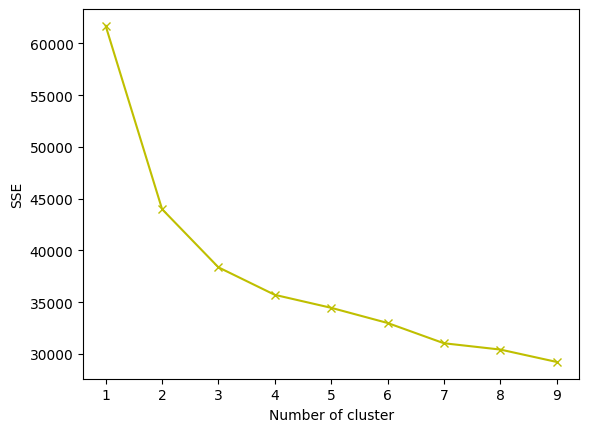

In [36]:
plt.figure()

plt.plot(list(sse.keys()), list(sse.values()), 'yx-') #'xy-'' plots the coordinates with line

plt.xlabel("Number of cluster")

plt.ylabel("SSE")

plt.show()

Since the elbow method did not yield clear clusters, the silhouette method was used to determine the optimal number of clusters.

### silhouette_score method to find optimal number of clusters

best_cluster: 2


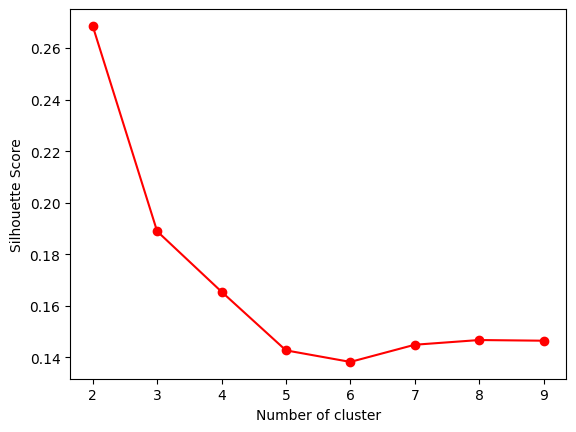

In [37]:
# Empty dictionary to store the Silhouette score for each value of K
sc = {}

# Iterate for a range of Ks and fit the scaled data to the algorithm. Store the Silhouette score for that K
for k in range(2, 10):
    kmeans = KMeans(n_clusters = k, random_state = 1).fit(df_k)
    labels = kmeans.labels_

    sc[k] = silhouette_score(df_k, labels)
    
best_k = max(sc, key=sc.get)
print('best_cluster:',best_k)


# Elbow plot
plt.figure()

plt.plot(list(sc.keys()), list(sc.values()), 'ro-')

plt.xlabel("Number of cluster")

plt.ylabel("Silhouette Score")

plt.show()

# pick highest value of silhouette_score

#### Applying KMeans clustering

In [38]:
kmeans = KMeans(n_clusters = 2, random_state = 1)
kmeans.fit(df_k)
kmeans_labels = kmeans.predict(df_k)

score_KMeans = silhouette_score(df_k, kmeans_labels)
print('KMeans silhouette:',score_KMeans)

data_k['KMeans_Labels'] = kmeans_labels

KMeans silhouette: 0.268574524350449


In [39]:
data_k[data_k['KMeans_Labels'] == 1]

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness__1-19_years,thinness_5-9_years,income_composition_of_resources,schooling,KMeans_Labels
16,Albania,2015,Developing,77.8,74.0,0,4.60,364.975229,99.0,0.000,...,6.00,99.0,0.1,3954.227830,28873.0,1.2,1.3,0.762,14.2,1
17,Albania,2014,Developing,77.5,8.0,0,4.51,428.749067,98.0,0.000,...,5.88,98.0,0.1,4575.763787,288914.0,1.2,1.3,0.761,14.2,1
18,Albania,2013,Developing,77.2,84.0,0,4.76,430.876979,99.0,0.000,...,5.66,99.0,0.1,4414.723140,289592.0,1.3,1.4,0.759,14.2,1
19,Albania,2012,Developing,76.9,86.0,0,5.14,412.443356,99.0,9.000,...,5.59,99.0,0.1,4247.614380,2941.0,1.3,1.4,0.752,14.2,1
20,Albania,2011,Developing,76.6,88.0,0,5.37,437.062100,99.0,28.000,...,5.71,99.0,0.1,4437.178680,295195.0,1.4,1.5,0.738,13.3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2869,Venezuela (Bolivarian Republic of),2004,Developing,73.3,161.0,10,7.55,0.000000,82.0,0.000,...,4.78,86.0,0.1,1766.947595,1386542.0,1.7,1.6,0.687,11.6,1
2870,Venezuela (Bolivarian Republic of),2003,Developing,72.4,172.0,10,6.30,0.000000,72.0,0.000,...,4.93,68.0,0.1,1766.947595,1386542.0,1.7,1.6,0.688,11.6,1
2871,Venezuela (Bolivarian Republic of),2002,Developing,73.1,167.0,10,6.89,0.000000,47.0,900.625,...,4.93,65.0,0.1,1766.947595,1386542.0,1.7,1.7,0.684,11.0,1
2872,Venezuela (Bolivarian Republic of),2001,Developing,72.5,169.0,10,8.05,0.000000,53.0,115.000,...,5.21,49.5,0.1,1766.947595,1386542.0,1.8,1.7,0.672,10.4,1


In [40]:
data_k['KMeans_Labels'].value_counts()

KMeans_Labels
1    1838
0    1100
Name: count, dtype: int64

In [41]:
data_k[data_k['KMeans_Labels']==0]['status'].value_counts()

status
Developing    1100
Name: count, dtype: int64

In [42]:
# Countries belonging to cluster 0:
print('Cluster 0 countries:\n', data_k[data_k['KMeans_Labels']==0]['country'].unique())
print('\nTotal countries in cluster 0:',data_k[data_k['KMeans_Labels']==0]['country'].nunique() )

Cluster 0 countries:
 ['Afghanistan' 'Algeria' 'Angola' 'Antigua and Barbuda' 'Azerbaijan'
 'Bangladesh' 'Benin' 'Bhutan' 'Botswana' 'Burkina Faso' 'Burundi'
 "Côte d'Ivoire" 'Cabo Verde' 'Cambodia' 'Cameroon'
 'Central African Republic' 'Chad' 'China' 'Comoros' 'Congo'
 "Democratic People's Republic of Korea"
 'Democratic Republic of the Congo' 'Djibouti' 'Dominican Republic'
 'Egypt' 'Equatorial Guinea' 'Eritrea' 'Ethiopia' 'Gabon' 'Gambia'
 'Georgia' 'Ghana' 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana' 'Haiti'
 'India' 'Indonesia' 'Iran (Islamic Republic of)' 'Iraq' 'Kenya'
 'Kiribati' "Lao People's Democratic Republic" 'Lebanon' 'Lesotho'
 'Liberia' 'Madagascar' 'Malawi' 'Malaysia' 'Maldives' 'Mali' 'Mauritania'
 'Morocco' 'Mozambique' 'Myanmar' 'Namibia' 'Nepal' 'Niger' 'Nigeria'
 'Pakistan' 'Papua New Guinea' 'Philippines' 'Rwanda' 'Saint Lucia'
 'Samoa' 'Sao Tome and Principe' 'Senegal' 'Sierra Leone'
 'Solomon Islands' 'Somalia' 'South Africa' 'South Sudan' 'Sri Lanka'
 'Sudan

In [43]:
data_k[data_k['KMeans_Labels']==1]['status'].value_counts()

status
Developing    1326
Developed      512
Name: count, dtype: int64

In [44]:
# Countries belonging to cluster 1:
print('Cluster 1 countries:\n', data_k[data_k['KMeans_Labels']==1]['country'].unique())
print('\nTotal countries in cluster 1:',data_k[data_k['KMeans_Labels']==1]['country'].nunique() )

Cluster 1 countries:
 ['Albania' 'Algeria' 'Antigua and Barbuda' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Barbados'
 'Belarus' 'Belgium' 'Belize' 'Bolivia (Plurinational State of)'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei Darussalam'
 'Bulgaria' 'Cabo Verde' 'Cambodia' 'Canada' 'Chile' 'China' 'Colombia'
 'Comoros' 'Cook Islands' 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus' 'Czechia'
 "Democratic People's Republic of Korea" 'Denmark' 'Dominica'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Estonia' 'Fiji'
 'Finland' 'France' 'Gabon' 'Georgia' 'Germany' 'Greece' 'Grenada'
 'Guatemala' 'Guyana' 'Honduras' 'Hungary' 'Iceland'
 'Iran (Islamic Republic of)' 'Ireland' 'Israel' 'Italy' 'Jamaica' 'Japan'
 'Jordan' 'Kazakhstan' 'Kiribati' 'Kuwait' 'Kyrgyzstan' 'Latvia' 'Lebanon'
 'Libya' 'Lithuania' 'Luxembourg' 'Malaysia' 'Maldives' 'Malta'
 'Marshall Islands' 'Mauritius' 'Mexico'
 'Micronesia (Federated States of)' 'Monaco' 'Mongolia' 'Mon

### KMeans cluster profiling

In [45]:
 # Calculating the mean and the median of the original data for each label
data_k = data_k.drop(columns = ["country","status"],axis =1)
    
mean = data_k.groupby('KMeans_Labels').mean()
median = data_k.groupby('KMeans_Labels').median()
    
df_kmeans = pd.concat([mean, median], axis = 0)
df_kmeans.index = ['0 Mean', '1 Mean', '0 Median', '1 Median']
    
df_kmeans.T.round()

,0 Mean,1 Mean,0 Median,1 Median
year,2007.0,2008.0,2007.0,2008.0
life_expectancy,60.0,75.0,59.0,75.0
adult_mortality,246.0,112.0,258.0,116.0
infant_deaths,30.0,4.0,29.0,1.0
alcohol,2.0,6.0,2.0,5.0
percentage_expenditure,72.0,411.0,23.0,224.0
hepatitis_b,79.0,90.0,87.0,94.0
measles,446.0,107.0,334.0,2.0
bmi,23.0,48.0,19.0,54.0
under-five_deaths,40.0,5.0,40.0,1.0


### Cluster 0:

Lower life expectancy and higher adult, infant, and under-five mortality.

Higher disease burden (e.g., measles, HIV/AIDS).

Lower vaccination coverage and health expenditure.

Lower GDP, income composition, and years of schooling.

Represents lower-income / less-developed countries.

### Cluster 1:

Higher life expectancy and much lower mortality rates.

Lower disease prevalence and strong immunization coverage.

Higher health expenditure, GDP, and education levels.

Represents higher-income / more-developed countries.

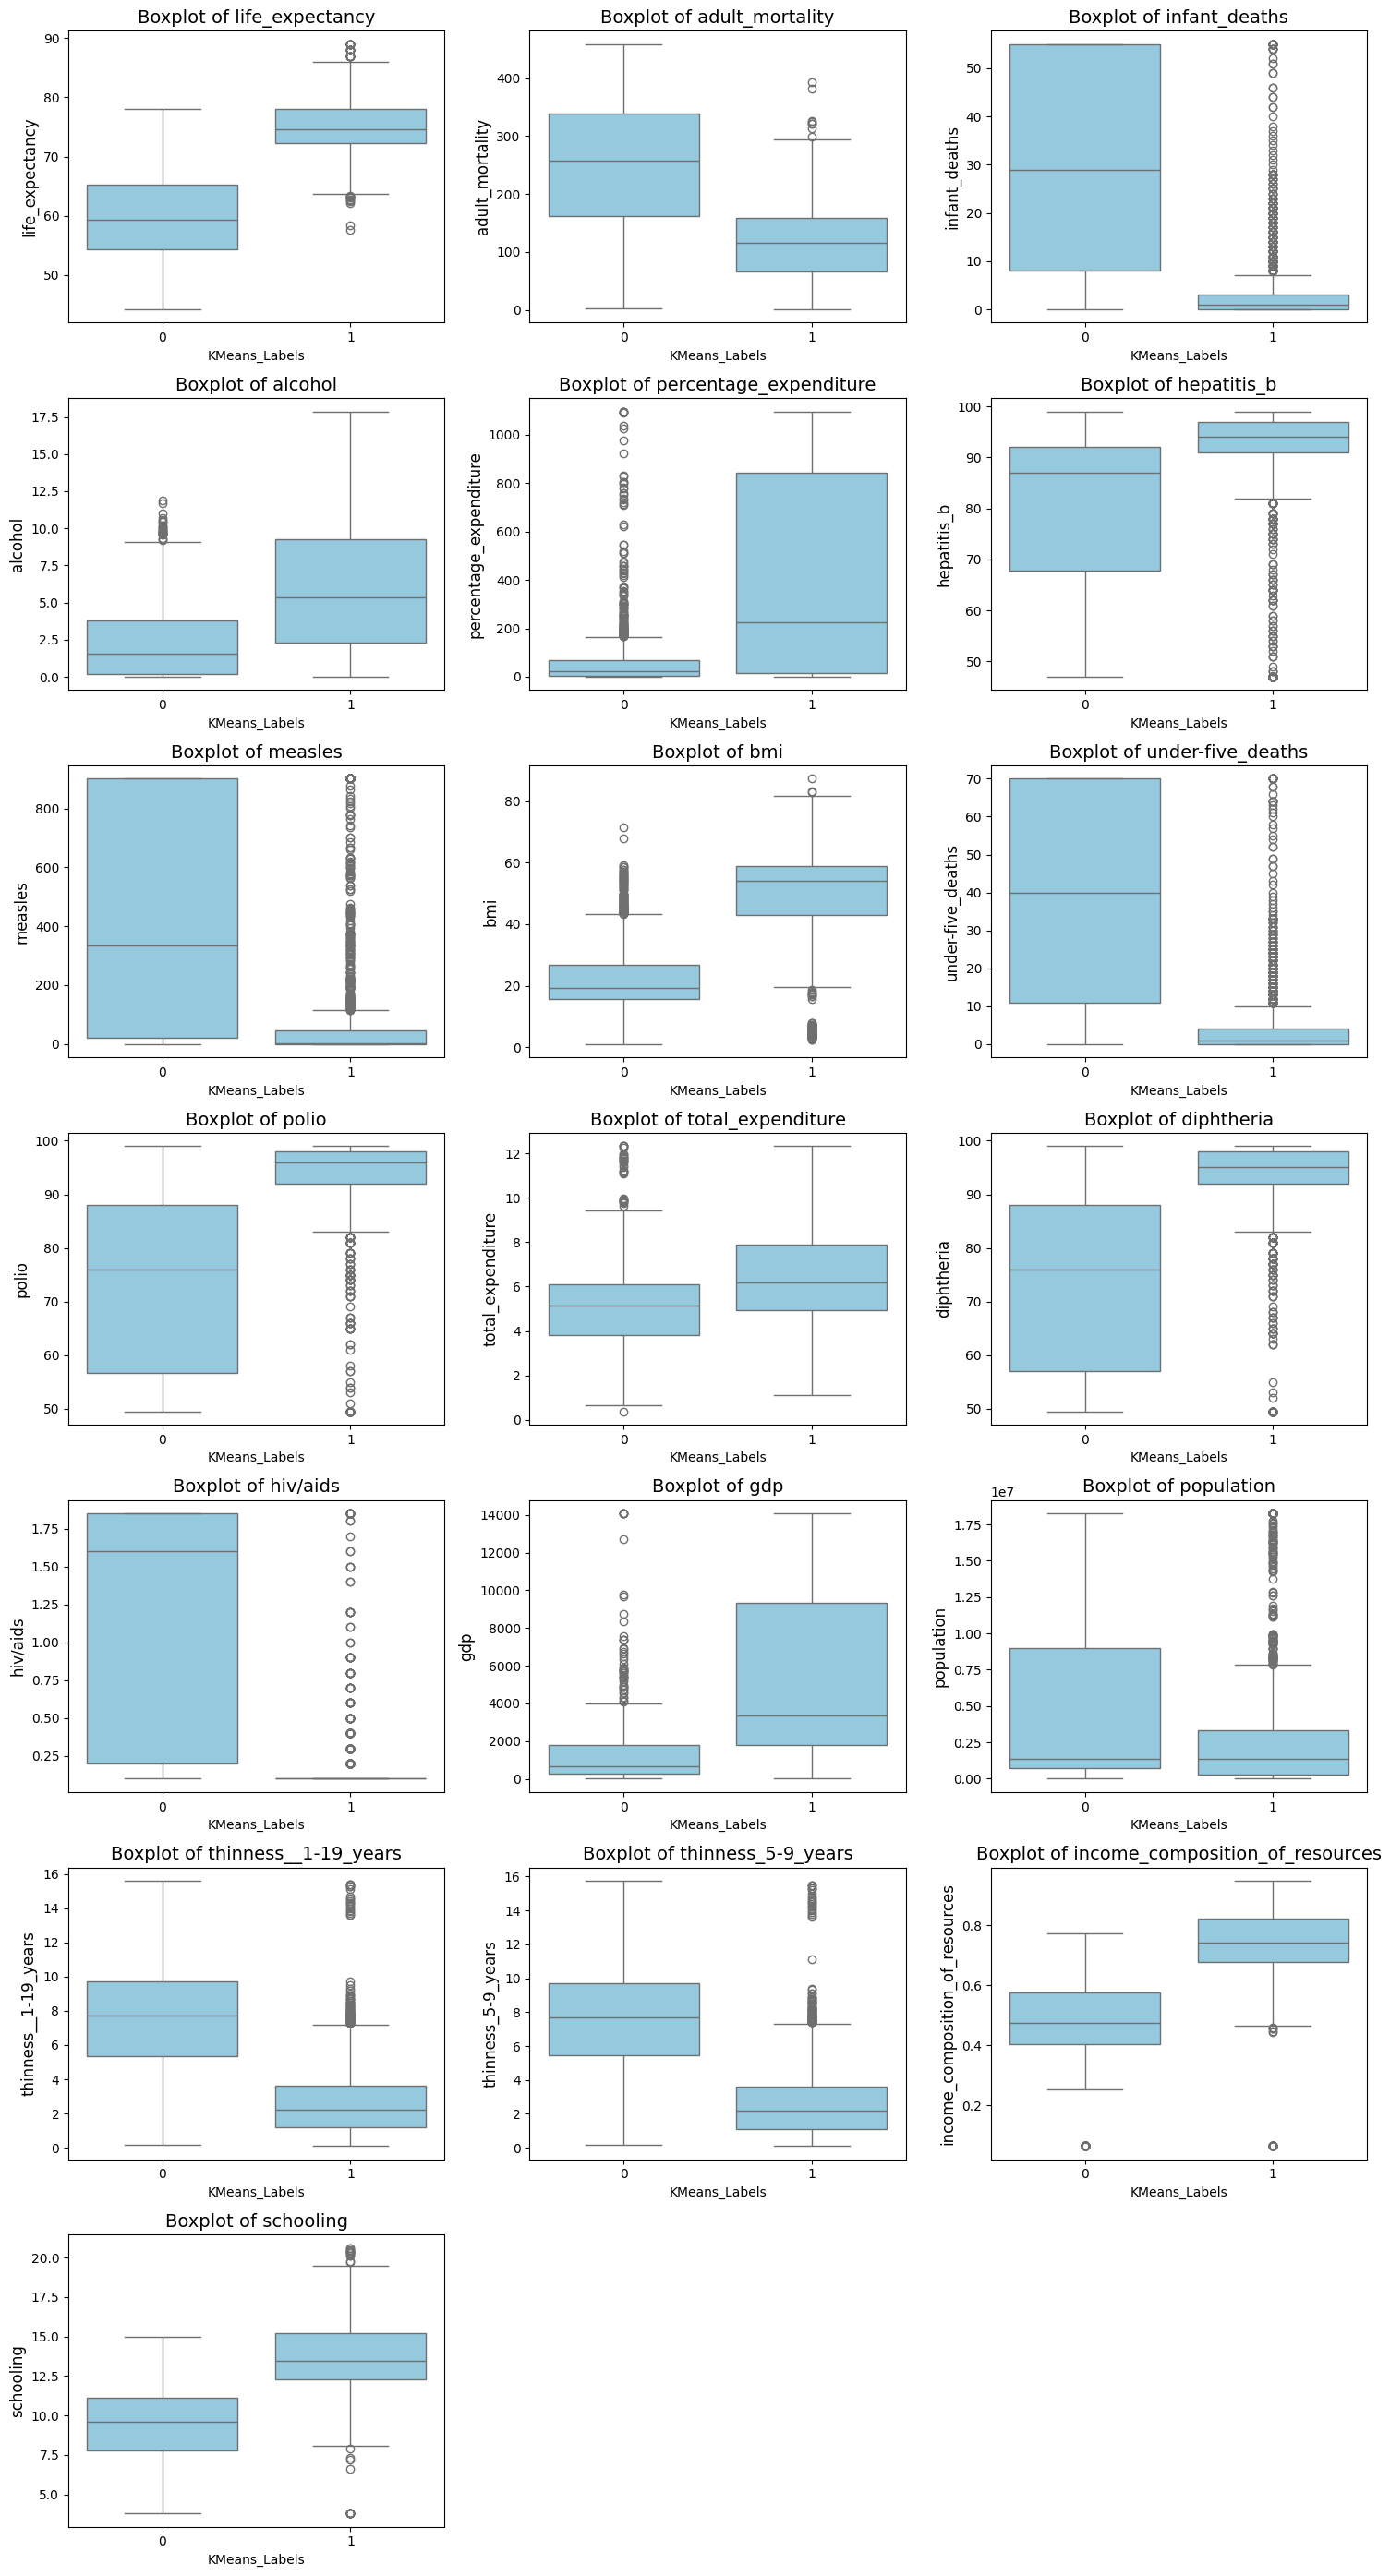

In [46]:
cols_visualise = ['life_expectancy', 'adult_mortality', 'infant_deaths','alcohol', 'percentage_expenditure', 'hepatitis_b', 'measles', 'bmi',
       'under-five_deaths', 'polio', 'total_expenditure', 'diphtheria','hiv/aids', 'gdp', 'population', 'thinness__1-19_years',
       'thinness_5-9_years', 'income_composition_of_resources', 'schooling']

import math    
n_plots = len(cols_visualise)
n_cols =3
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_visualise):
    ax = axes[i]
    sns.boxplot(x = 'KMeans_Labels',
                y = col, 
                data = data_k,
                ax=ax,
                color = 'skyblue'
        )
    ax.set_title(f'Boxplot of {col}', fontsize=14)
    ax.set_ylabel(col, fontsize=12)

 # Remove empty axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### KMeans Feature importance

In [47]:
# method 1 clusters centers
centers= pd.DataFrame(kmeans.cluster_centers_, columns = df_k.columns)

feature_importance = centers.max() - centers.min()
feature_importance.sort_values(ascending=False).head(5) # Top  5 features


life_expectancy                    1.599094
schooling                          1.417289
hiv/aids                           1.399476
under-five_deaths                  1.383602
income_composition_of_resources    1.340260
dtype: float64

## Model 2 Hierarchical Clustering

In [48]:
from scipy.cluster.hierarchy import dendrogram, linkage

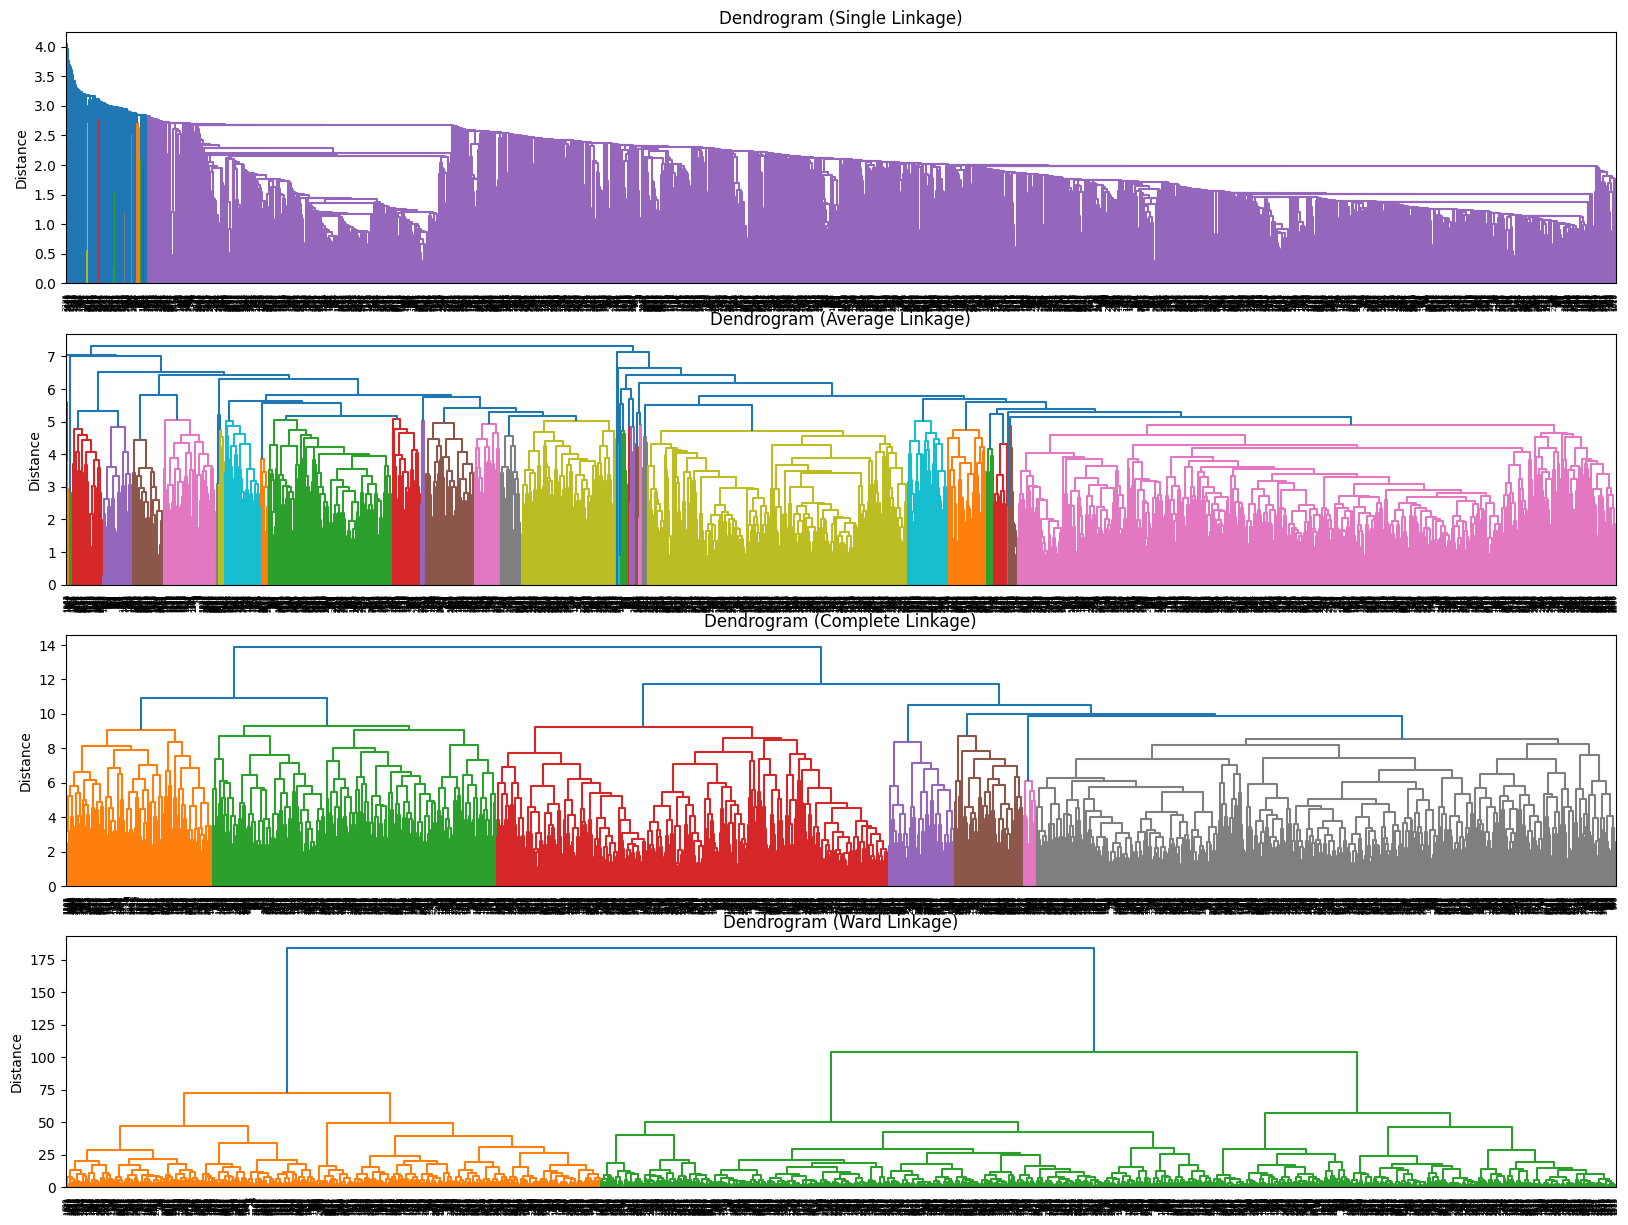

In [49]:
# The List of all linkage methods to check
methods = ['single',   
           'average',  
           'complete',
            'ward'] 

# Create a subplot image
fig, axs = plt.subplots(len(methods), 1, figsize = (20, 15))


for i, method in enumerate(methods):
    Z = linkage(df_hr, metric = 'euclidean', method = method)

    dendrogram(Z, ax = axs[i]);

    axs[i].set_title(f'Dendrogram ({method.capitalize()} Linkage)')

    axs[i].set_ylabel('Distance')
    

### Plot dendrogram to find optimal clusters

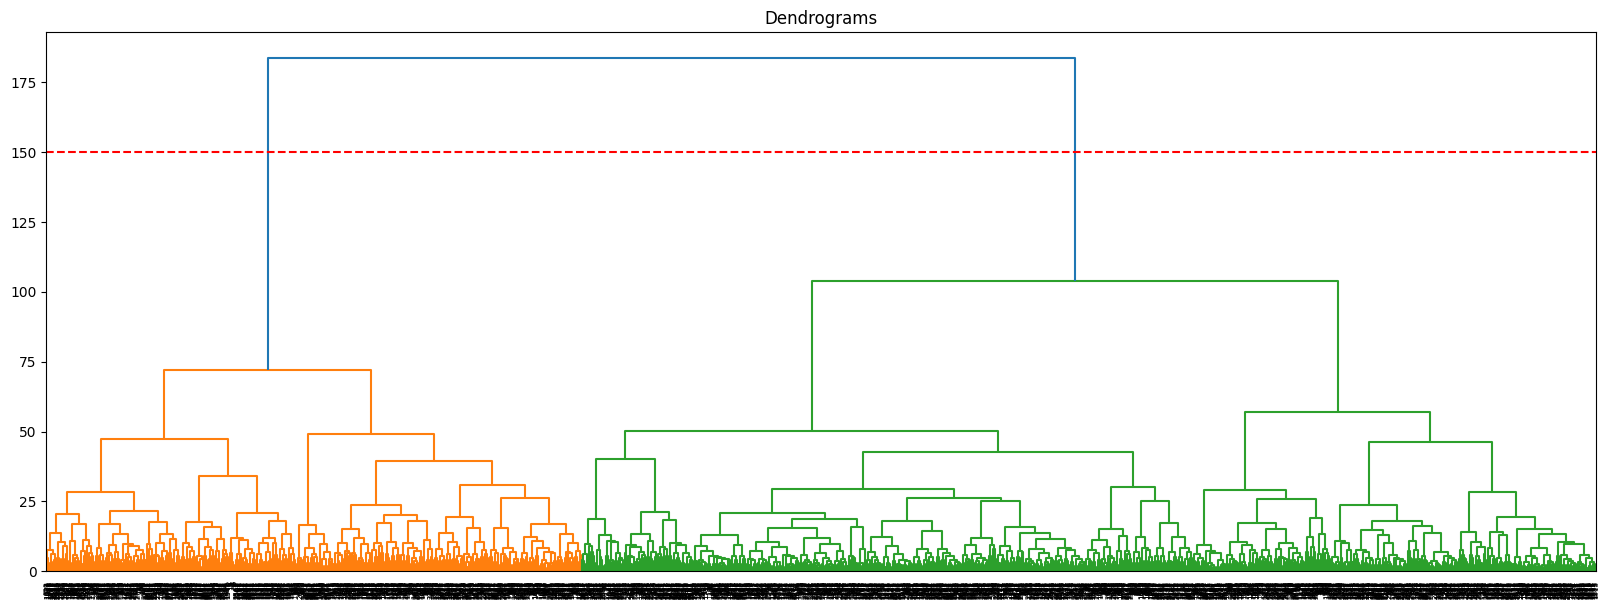

In [50]:
plt.figure(figsize =(20,7))
plt.title('Dendrograms')
dend = dendrogram(linkage(df_hr, method = 'ward'))
plt.axhline(y= 150, color = 'r', linestyle  = '--')


### silhouette_score method


Best Clustering:
Linkage Method: Ward
Number of Clusters: 2
Silhouette Score: 0.2648


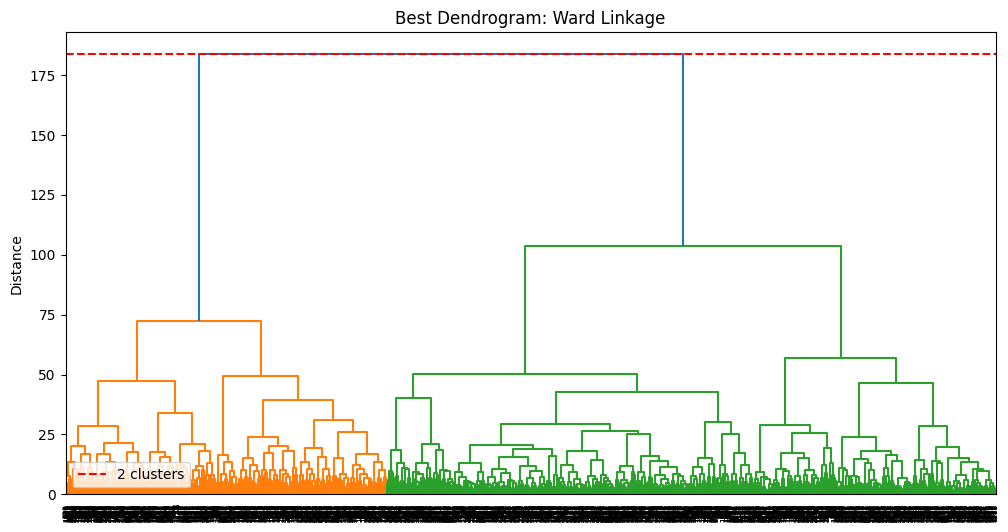

In [51]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import silhouette_score

# Define linkage methods and cluster range
linkage_methods = ['single', 'complete', 'average', 'ward']
cluster_range = range(2, 10)

results = {}  # Dictionary to store silhouette scores

# Loop through each method and number of clusters
for method in linkage_methods:
    Z = linkage(df_hr, method=method)
    
    for k in cluster_range:
        labels = fcluster(Z, t=k, criterion='maxclust') #  t is  a threshold value that controls how the dendrogram is cut to form clusters.
        score = silhouette_score(df_hr, labels)

        results[(method, k)] = score
        # print(f"Method: {method.capitalize()}, Clusters: {k}, Silhouette Score: {score:.4f}")

# Find the best method and cluster count
best_method, best_k = max(results, key=results.get)
best_score = results[(best_method, best_k)]

print("\nBest Clustering:")
print(f"Linkage Method: {best_method.capitalize()}")
print(f"Number of Clusters: {best_k}")
print(f"Silhouette Score: {best_score:.4f}")

# Plot dendrogram for the best method
Z_best = linkage(df_hr, method=best_method)

plt.figure(figsize=(12, 6))
dendrogram(Z_best)
plt.title(f"Best Dendrogram: {best_method.capitalize()} Linkage")
plt.axhline(y=Z_best[-(best_k-1), 2], color='red', linestyle='--', label=f'{best_k} clusters')
plt.ylabel("Distance")
plt.legend()
plt.show()

### from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

Z = linkage(df_hr, method='ward')  
hier_labels = fcluster(Z, t=2, criterion='maxclust')


### Agglomerative Clustering

In [52]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters = 2, metric = 'euclidean', linkage = 'ward')

hierarchical.fit(df_hr)
hier_labels = hierarchical.labels_
df_hr['HCLabels'] = hier_labels
data_hr['HCLabels'] = hier_labels

score_hier = silhouette_score(df_hr, hier_labels)
print('Hierarchical silhouette:',score_hier)

Hierarchical silhouette: 0.27225467636537554


In [53]:
data_hr

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness__1-19_years,thinness_5-9_years,income_composition_of_resources,schooling,HCLabels
0,Afghanistan,2015,Developing,65.0,263.0,55,0.01,71.279624,65.0,900.625,...,8.16,65.0,0.10,584.259210,1.825721e+07,15.6,15.75,0.479,10.1,1
1,Afghanistan,2014,Developing,59.9,271.0,55,0.01,73.523582,62.0,492.000,...,8.18,62.0,0.10,612.696514,3.275820e+05,15.6,15.75,0.476,10.0,1
2,Afghanistan,2013,Developing,59.9,268.0,55,0.01,73.219243,64.0,430.000,...,8.13,64.0,0.10,631.744976,1.825721e+07,15.6,15.75,0.470,9.9,1
3,Afghanistan,2012,Developing,59.5,272.0,55,0.01,78.184215,67.0,900.625,...,8.52,67.0,0.10,669.959000,3.696958e+06,15.6,15.75,0.463,9.8,1
4,Afghanistan,2011,Developing,59.2,275.0,55,0.01,7.097109,68.0,900.625,...,7.87,68.0,0.10,63.537231,2.978599e+06,15.6,15.75,0.454,9.5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,459.0,27,4.36,0.000000,68.0,31.000,...,7.13,65.0,1.85,454.366654,1.277751e+07,9.4,9.40,0.407,9.2,1
2934,Zimbabwe,2003,Developing,44.5,459.0,26,4.06,0.000000,47.0,900.625,...,6.52,68.0,1.85,453.351155,1.263390e+07,9.8,9.90,0.418,9.5,1
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304.000,...,6.53,71.0,1.85,57.348340,1.255250e+05,1.2,1.30,0.427,10.0,1
2936,Zimbabwe,2001,Developing,45.3,459.0,25,1.72,0.000000,76.0,529.000,...,6.16,75.0,1.85,548.587312,1.236616e+07,1.6,1.70,0.427,9.8,1


In [54]:
data_hr.HCLabels.value_counts()

HCLabels
0    1923
1    1015
Name: count, dtype: int64

In [55]:
print(data_hr[data_hr['HCLabels']==0]['status'].value_counts())

status
Developing    1411
Developed      512
Name: count, dtype: int64


In [56]:
# Countries belonging to cluster 0:
print('Cluster 0 countries:\n', data_hr[data_hr['HCLabels']==0]['country'].unique())
print('\nTotal countries in cluster 0:',data_hr[data_hr['HCLabels']==0]['country'].nunique())

Cluster 0 countries:
 ['Albania' 'Algeria' 'Antigua and Barbuda' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Barbados'
 'Belarus' 'Belgium' 'Belize' 'Bolivia (Plurinational State of)'
 'Bosnia and Herzegovina' 'Brazil' 'Brunei Darussalam' 'Bulgaria'
 'Cabo Verde' 'Cambodia' 'Canada' 'Chile' 'China' 'Colombia' 'Comoros'
 'Cook Islands' 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus' 'Czechia'
 "Democratic People's Republic of Korea" 'Denmark' 'Dominica'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Estonia' 'Fiji'
 'Finland' 'France' 'Georgia' 'Germany' 'Ghana' 'Greece' 'Grenada'
 'Guatemala' 'Guyana' 'Haiti' 'Honduras' 'Hungary' 'Iceland'
 'Iran (Islamic Republic of)' 'Iraq' 'Ireland' 'Israel' 'Italy' 'Jamaica'
 'Japan' 'Jordan' 'Kazakhstan' 'Kiribati' 'Kuwait' 'Kyrgyzstan' 'Latvia'
 'Lebanon' 'Libya' 'Lithuania' 'Luxembourg' 'Madagascar' 'Malaysia'
 'Malta' 'Marshall Islands' 'Mauritius' 'Mexico'
 'Micronesia (Federated States of)' 'Monaco' 'Mongolia

In [57]:
print(data_hr[data_hr['HCLabels']==1]['status'].value_counts())

status
Developing    1015
Name: count, dtype: int64


In [58]:
# Countries belonging to cluster 1:
print('Cluster 0 countries:\n', data_hr[data_hr['HCLabels']==1]['country'].unique())
print('\nTotal countries in cluster 0:',data_hr[data_hr['HCLabels']==1]['country'].nunique())

Cluster 0 countries:
 ['Afghanistan' 'Angola' 'Bangladesh' 'Benin' 'Bhutan' 'Botswana'
 'Burkina Faso' 'Burundi' "Côte d'Ivoire" 'Cambodia' 'Cameroon'
 'Central African Republic' 'Chad' 'China' 'Comoros' 'Congo'
 'Democratic Republic of the Congo' 'Djibouti' 'Equatorial Guinea'
 'Eritrea' 'Ethiopia' 'Gabon' 'Gambia' 'Ghana' 'Guatemala' 'Guinea'
 'Guinea-Bissau' 'Guyana' 'Haiti' 'India' 'Indonesia' 'Iraq' 'Kenya'
 "Lao People's Democratic Republic" 'Lesotho' 'Liberia' 'Madagascar'
 'Malawi' 'Maldives' 'Mali' 'Mauritania' 'Mozambique' 'Myanmar' 'Namibia'
 'Nepal' 'Niger' 'Nigeria' 'Pakistan' 'Papua New Guinea' 'Philippines'
 'Rwanda' 'Samoa' 'Sao Tome and Principe' 'Senegal' 'Sierra Leone'
 'Somalia' 'South Africa' 'South Sudan' 'Sri Lanka' 'Sudan' 'Swaziland'
 'Timor-Leste' 'Togo' 'Trinidad and Tobago' 'Turkey' 'Uganda'
 'United Republic of Tanzania' 'Viet Nam' 'Yemen' 'Zambia' 'Zimbabwe']

Total countries in cluster 0: 71


### Hierarchical cluster profiling

In [59]:
# Calculating the mean and the median of the original data for each label
data_hr = data_hr.drop(columns = ["country","status"],axis =1)

mean = data_hr.groupby('HCLabels').mean()

median = data_hr.groupby('HCLabels').median()

df_hier = pd.concat([mean, median], axis = 0)
# axis = 0  --> row wise stack one above another
# axis = 1 --> column wise

df_hier.index = ['0 Mean', '1 Mean', '0 Median', '1 Median']

df_hier.T.round()

,0 Mean,1 Mean,0 Median,1 Median
year,2008.0,2007.0,2008.0,2007.0
life_expectancy,75.0,59.0,74.0,59.0
adult_mortality,115.0,252.0,121.0,268.0
infant_deaths,5.0,30.0,1.0,29.0
alcohol,6.0,3.0,5.0,2.0
percentage_expenditure,391.0,81.0,192.0,23.0
hepatitis_b,89.0,80.0,93.0,88.0
measles,125.0,440.0,2.0,314.0
bmi,48.0,21.0,54.0,19.0
under-five_deaths,6.0,41.0,1.0,43.0


- Cluster 0 represents developed or better-off countries with good health indicators, high life expectancy, low mortality, good vaccination coverage, higher GDP, and better social indicators.
- Cluster 1 represents developing or poorer countries with worse health outcomes, low life expectancy, higher mortality, undernutrition, and lower economic and social indicators.

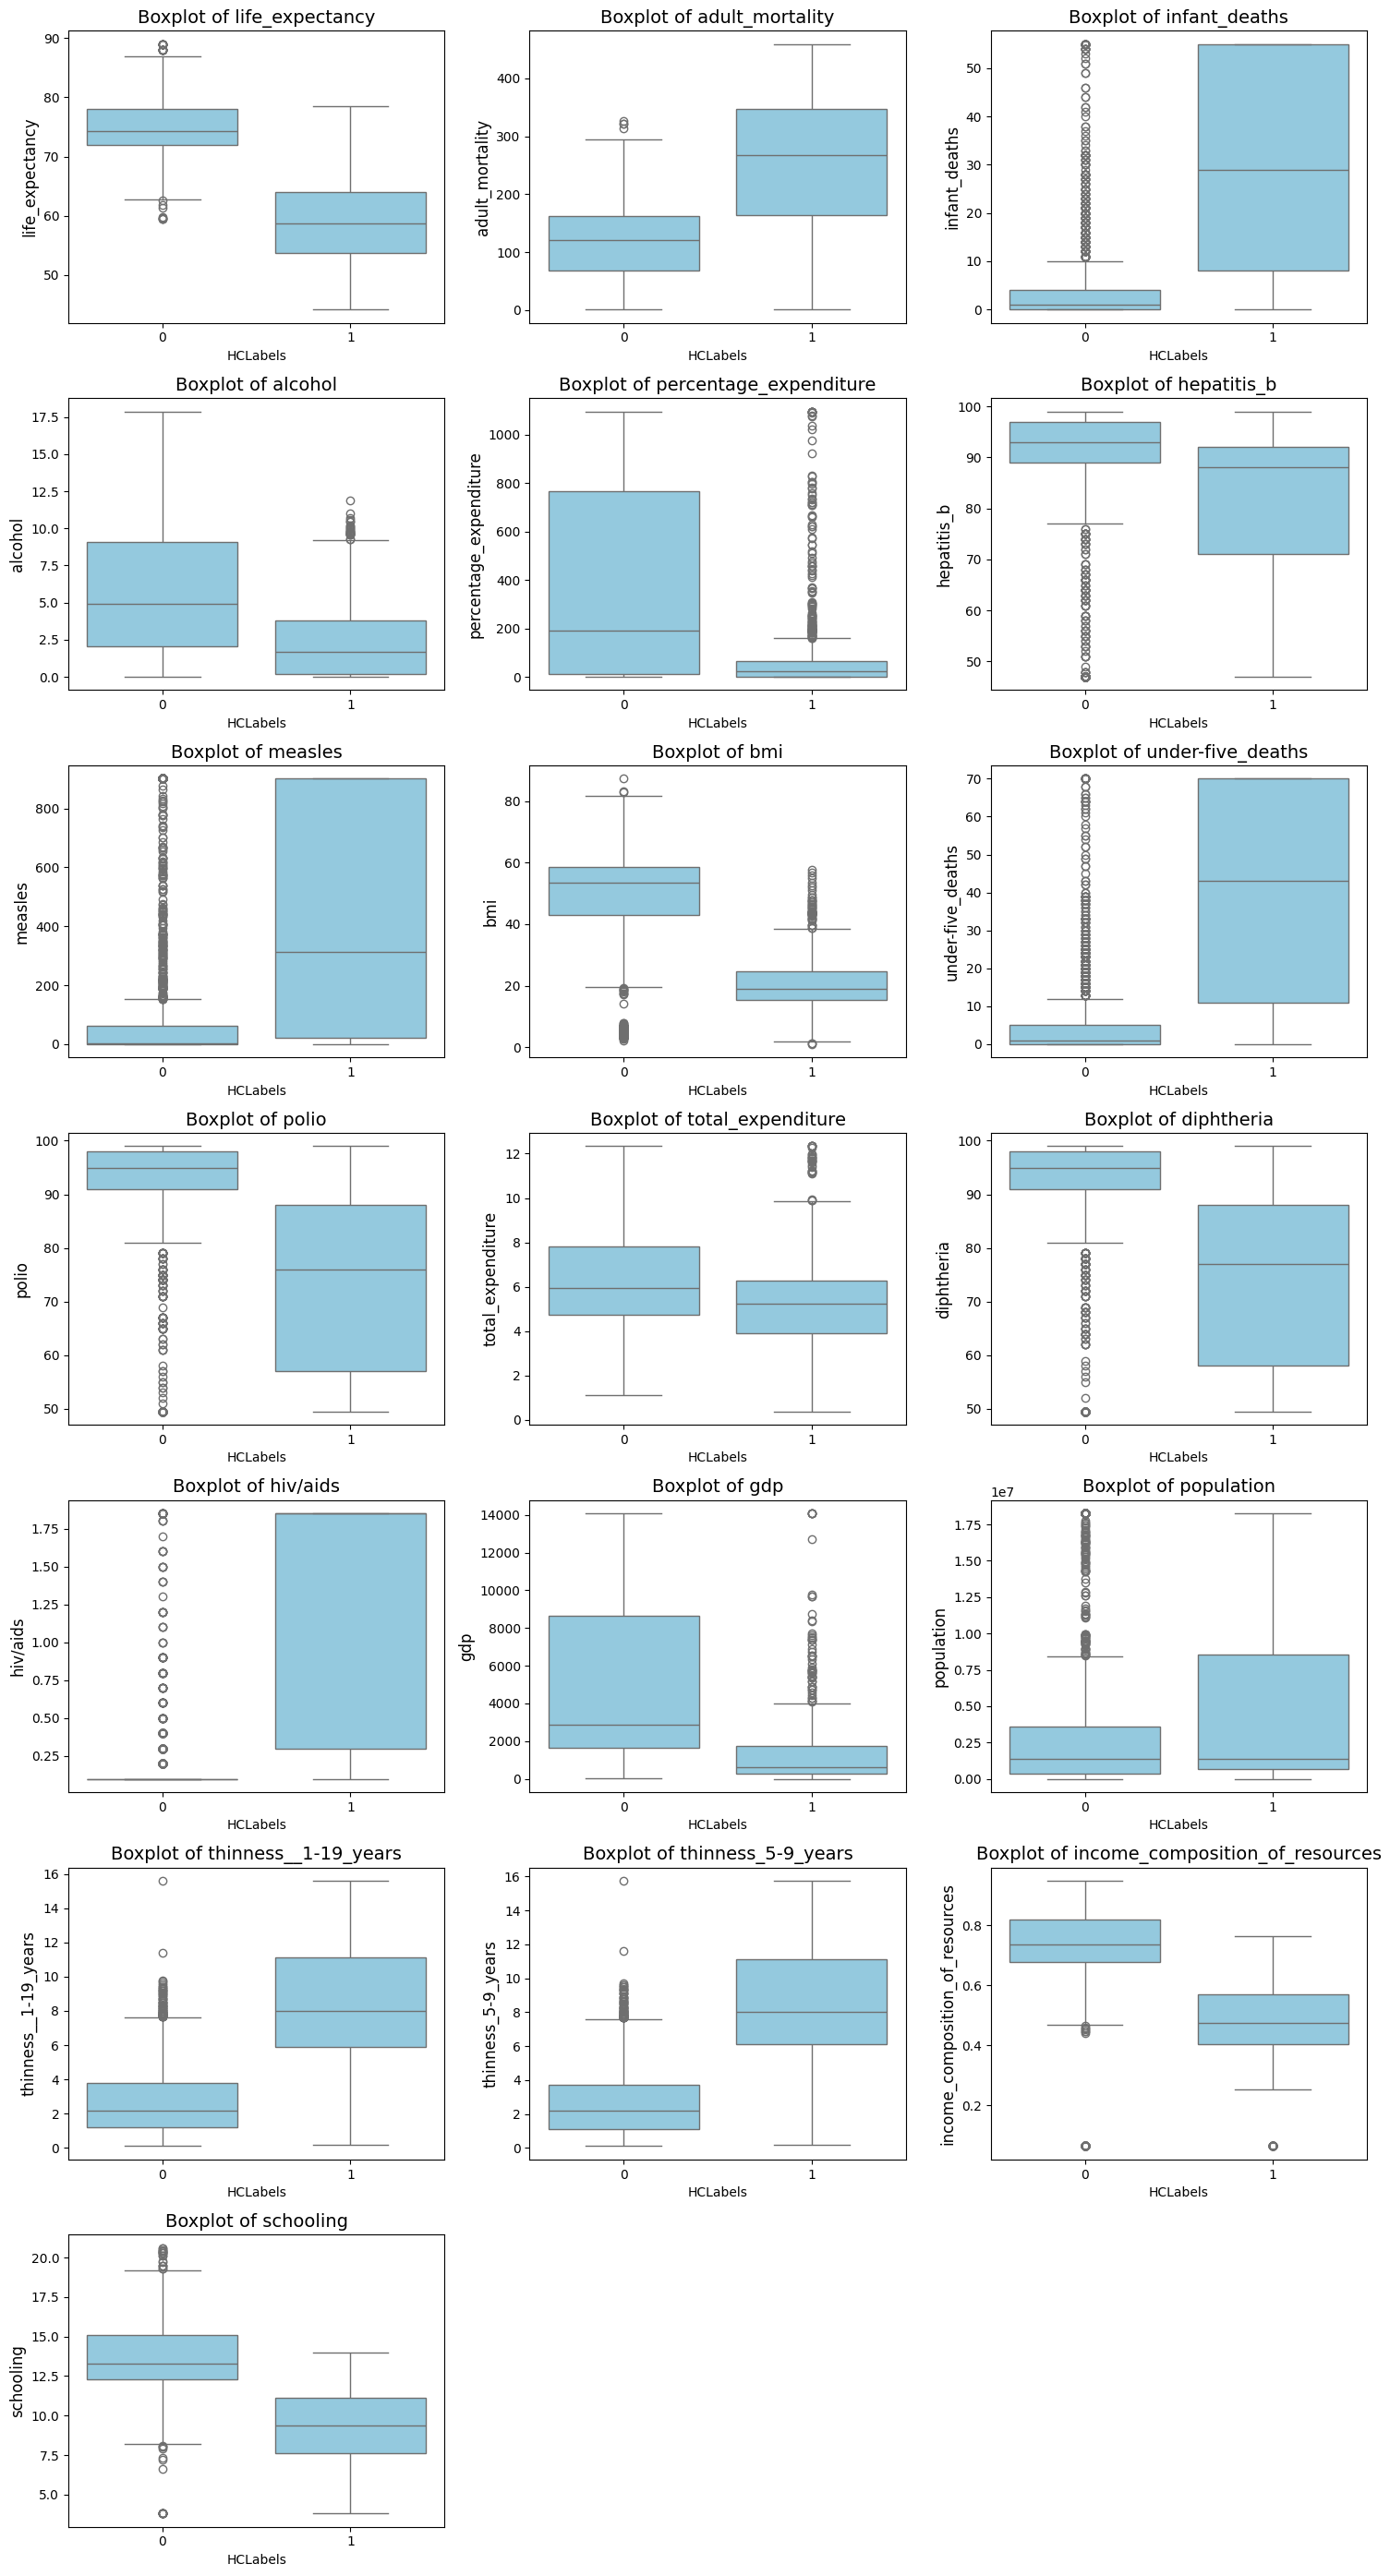

In [60]:

cols_visualise = ['life_expectancy', 'adult_mortality', 'infant_deaths','alcohol', 'percentage_expenditure', 'hepatitis_b', 'measles', 'bmi',
       'under-five_deaths', 'polio', 'total_expenditure', 'diphtheria','hiv/aids', 'gdp', 'population', 'thinness__1-19_years',
       'thinness_5-9_years', 'income_composition_of_resources', 'schooling']

import math    

n_plots = len(cols_visualise)
n_cols =3
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_visualise):
    ax = axes[i]
    sns.boxplot(x = 'HCLabels',
                y = col, 
                data = data_hr,
                ax=ax,
                color = 'skyblue'
        )
    ax.set_title(f'Boxplot of {col}', fontsize=14)
    ax.set_ylabel(col, fontsize=12)

 # Remove empty axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Comparing KMeans vs Hierarchical clustering

### PCA visualization

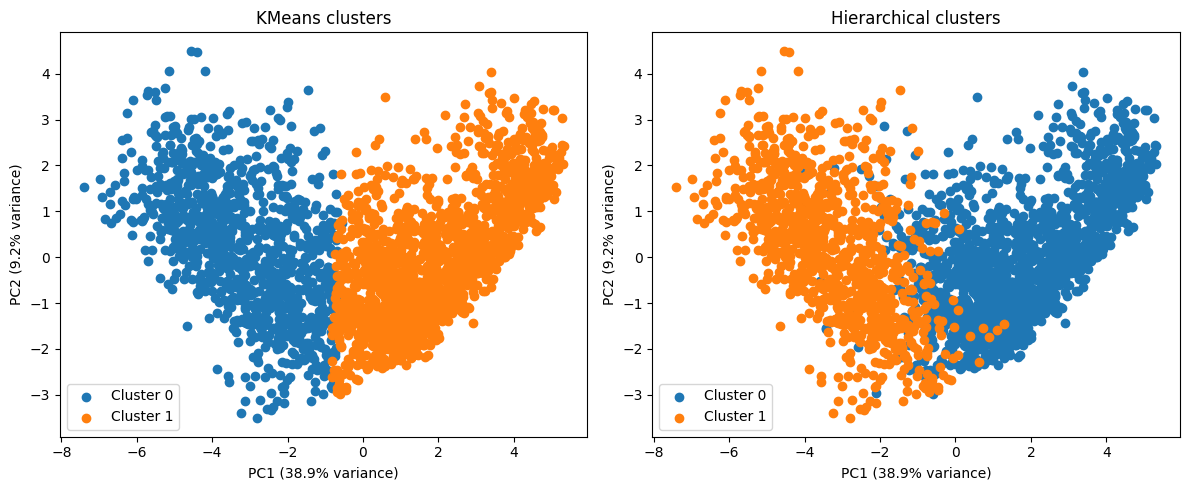

In [61]:
from sklearn.decomposition import PCA

# Reduce to 2D using PCA
pca = PCA(n_components=2)
pca_2d = pca.fit_transform(df_k)
explained_var = pca.explained_variance_ratio_ * 100
pc1_var, pc2_var = explained_var[0], explained_var[1]

# Fit KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(df_k)

# Fit Hierarchical clustering
hierarchical = AgglomerativeClustering(n_clusters=2, linkage='ward')
hier_labels = hierarchical.fit_predict(df_k)

# Plot both clusters in 2D PCA space
plt.figure(figsize=(12,5))

# KMeans clusters
plt.subplot(1,2,1)
for label in np.unique(kmeans_labels):
    plt.scatter(
        pca_2d[kmeans_labels==label, 0],
        pca_2d[kmeans_labels==label, 1],
        label=f"Cluster {label}"
    )
plt.title("KMeans clusters")
plt.xlabel(f"PC1 ({pc1_var:.1f}% variance)")
plt.ylabel(f"PC2 ({pc2_var:.1f}% variance)")
plt.legend()

# Hierarchical clusters
plt.subplot(1,2,2)
for label in np.unique(hier_labels):
    plt.scatter(
        pca_2d[hier_labels==label, 0],
        pca_2d[hier_labels==label, 1],
        label=f"Cluster {label}"
    )
plt.title("Hierarchical clusters")
plt.xlabel(f"PC1 ({pc1_var:.1f}% variance)")
plt.ylabel(f"PC2 ({pc2_var:.1f}% variance)")
plt.legend()

plt.tight_layout()
plt.show()


The PCA 2D plot provides a visual assessment of how clusters appear separated or overlapped in the reduced feature space; however, cluster validity is evaluated using quantitative metrics in the original feature space.

### Cluster quality

In [62]:
print('KMeans silhouette:',score_KMeans)
print('Hierarchical silhouette:',score_hier)

KMeans silhouette: 0.268574524350449
Hierarchical silhouette: 0.27225467636537554


### Comparison of KMeans and Hierarchical Clustering Observation

- **PCA visualization**: KMeans clusters appear more separated along PCA 1, while hierarchical clusters overlap in the 2D projection.

- **Silhouette score**: Hierarchical has a slightly higher score (0.272) than KMeans (0.269), indicating it preserves cluster structure in the original high-dimensional space a bit better.

### Interpretation: 
- KMeans gives clearer visual separation, but hierarchical captures true distances slightly more accurately; overall, both methods show moderate cluster separation.